# 24.
- Berkowitz - bada rozklad i przekroczenia - bardziej reasarchowe niz biznesowe
- Basel prawie to samo co kupca - ofc Kupca i Christoffersena tez   --- ML, LSTM
- VAR - uzyc EWMA - im dalej od terazniejszosci tym mniejsza waga, $\lambda = 0.97$ dla equities przykladowo, estymator hilla - liczenie lambdy na egzaminie
- GARCH - metoda filtrowanej symulacji historycznej - najczesciej (1,1) jako rzad modelu, EWMA (ruchoma srednia) plus ostatnie obserwacje, sigma 0 = std dev log returns 60d
- MC - ARMA GARCH symulator MC, GBM jako log zwroty do rozkladu normalnego (Levy),

---
**Notki kierunkowe (rozszerzenia poza zakres tej prezentacji):**
- **ML / LSTM** — alternatywa do GARCH dla prognozowania zmiennosci; testy Kupca / Christoffersena / Bazylejski stosuje sie tak samo (oceniaja przekroczenia, nie model).
- **Hill / EWMA $\lambda$** — na egzaminie liczymy $\lambda$ z estymatora Hilla (sekcja 1b.iv); typowe $\lambda = 0.97$ dla akcji (RiskMetrics).
- **GBM jako proces Levy'ego** — log-zwroty ~ Normal, cienkie ogony — patrz sekcja 1c.iii (MC GBM).


# Projekt 3 — VaR i EVaR dla XTB.WA
## Zarządzanie Ryzykiem w Przedsiębiorstwie

**Zmienna ryzyka:** log-zwroty akcji **XTB S.A. (XTB.WA)** — najbardziej zmienna spośród wcześniej analizowanych (por. prez3). Wybór jednej zmiennej pozwala jednoznacznie porównać miary ryzyka.

**Zakres pracy:**
1. Obliczenie **VaR₉₅%** i **VaR₉₉%** metodami:
   - **(a)** parametryczną — rozkład t-Studenta
   - **(b)** historyczną — (i) zwykłą, (ii) ważoną wiekowo (BRW), (iii) z filtrowaniem GARCH (FHS)
   - **(c)** Monte Carlo — symulacja z dopasowanego rozkładu t-Studenta
2. **Backtesting** (Kupiec POF + Christoffersen niezależność) dla 1a, 1b, 1c.
3. Powtórzenie pkt. 1–2 dla **EVaR** (ekspektylowej wartości zagrożonej).

**Konwencja:** pracujemy na log-zwrotach `R`; *strata* to `L = −R`. VaR i EVaR raportujemy jako wartości dodatnie (oczekiwana strata na poziomie istotności). 

In [32]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, t as t_dist
from scipy.optimize import brentq
from arch import arch_model
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.random.seed(42)

# ---------- Pobieranie danych ----------
prices = yf.download('XTB.WA', start='2018-01-01', end='2025-12-31', progress=False)['Close']
prices = prices.dropna()
log_returns = np.log(prices / prices.shift(1)).dropna().squeeze()
log_returns.name = 'XTB.WA'

losses = -log_returns  # strata jako wartość dodatnia, gdy zwrot ujemny

print(f"Okres:                 {prices.index[0].date()} — {prices.index[-1].date()}")
print(f"Liczba obserwacji:     {len(log_returns)}")
print(f"Średnia log-zwrotu:    {log_returns.mean():.5f}")
print(f"Odch. std.:            {log_returns.std():.5f}")
print(f"Skośność:              {log_returns.skew():.3f}")
print(f"Kurtoza (excess):      {log_returns.kurtosis():.3f}")
print(f"Min / Max:             {log_returns.min():.4f} / {log_returns.max():.4f}")

Okres:                 2018-01-01 — 2025-12-30
Liczba obserwacji:     2030
Średnia log-zwrotu:    0.00166
Odch. std.:            0.02952
Skośność:              -0.443
Kurtoza (excess):      25.429
Min / Max:             -0.3760 / 0.3059


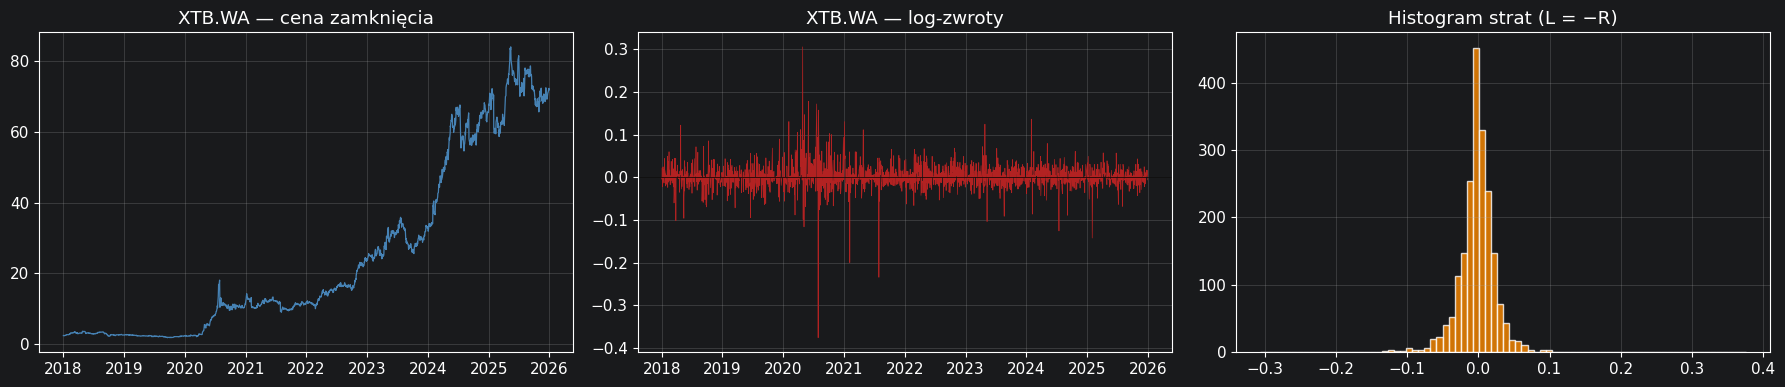

In [33]:
# Wizualizacja — ceny, log-zwroty, histogram strat
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(prices.index, prices.values, color='steelblue', lw=0.9)
axes[0].set_title('XTB.WA — cena zamknięcia'); axes[0].grid(alpha=0.3)

axes[1].plot(log_returns.index, log_returns.values, color='firebrick', lw=0.5)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('XTB.WA — log-zwroty'); axes[1].grid(alpha=0.3)

axes[2].hist(losses, bins=80, color='darkorange', edgecolor='white', alpha=0.8)
axes[2].set_title('Histogram strat (L = −R)'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 1. Obliczenie VaR₉₅% i VaR₉₉%

Poziomy istotności: `α ∈ {0.05, 0.01}`; poziomy ufności: `1−α ∈ {0.95, 0.99}`.

VaR definiujemy jako:
$$
\mathrm{VaR}_{1-\alpha}(L) = \inf\{l : P(L \le l) \ge 1-\alpha\} = q_{1-\alpha}(L)
$$
gdzie `L = −R` to strata. Dla zwrotów `R` równoważnie `VaR_{1−α}(R) = −q_α(R)`.

## 1a. Metoda parametryczna — rozkład t-Studenta

Dopasowujemy rozkład **t-Studenta** (grube ogony — typowe dla zwrotów akcji). Dla dopasowanych parametrów `(ν, μ, σ)` VaR wynosi:
$$
\mathrm{VaR}_{1-\alpha} = -\left(\mu + \sigma \cdot t_\nu^{-1}(\alpha)\right)
$$

In [34]:
# --- 1a. Parametryczna VaR: t-Studenta ---
alpha_list = [0.05, 0.01]
confidence = [1 - a for a in alpha_list]

r = log_returns.values
df_t, loc_t, scale_t = t_dist.fit(r)
mu_n, sig_n = r.mean(), r.std()

print(f"Dopasowanie t-Studenta:  ν = {df_t:.2f},  μ = {loc_t:.5f},  σ = {scale_t:.5f}")
print(f"Dopasowanie Normal:      μ = {mu_n:.5f},  σ = {sig_n:.5f}\n")

var_param = {}
for a in alpha_list:
    q_t = t_dist.ppf(a, df_t, loc=loc_t, scale=scale_t)
    q_n = norm.ppf(a, loc=mu_n, scale=sig_n)
    var_param[a] = {'t': -q_t, 'norm': -q_n}
    print(f"VaR {int((1-a)*100)}% (t-Student):  {-q_t:.4f}    "
          f"VaR {int((1-a)*100)}% (Normal): {-q_n:.4f}")

Dopasowanie t-Studenta:  ν = 2.56,  μ = 0.00058,  σ = 0.01562
Dopasowanie Normal:      μ = 0.00166,  σ = 0.02951

VaR 95% (t-Student):  0.0389    VaR 95% (Normal): 0.0469
VaR 99% (t-Student):  0.0811    VaR 99% (Normal): 0.0670


## 1b.i. Metoda historyczna — zwykła

Empiryczny kwantyl strat: `VaR = −percentile(R, α·100)`. Nie zakłada rozkładu, ale traktuje wszystkie obserwacje jednakowo.

In [35]:
# --- 1b.i Historical Simulation (HS) ---
var_hs = {}
for a in alpha_list:
    q_emp = np.percentile(r, a * 100)
    var_hs[a] = -q_emp
    print(f"VaR {int((1-a)*100)}% (HS zwykła):  {-q_emp:.4f}")

VaR 95% (HS zwykła):  0.0358
VaR 99% (HS zwykła):  0.0677


## 1b.ii. Metoda historyczna ważona (BRW — Boudoukh, Richardson, Whitelaw 1998)

Najnowsze obserwacje dostają większą wagę:
$$
w_i = \frac{\lambda^{\,n-i}\,(1-\lambda)}{1-\lambda^n}, \qquad i=1,\dots,n
$$
gdzie `λ ∈ (0,1)` (tu **λ = 0.995**). VaR to **ważony kwantyl** sortowanych zwrotów.

In [36]:
# --- 1b.ii Age-weighted HS (BRW) ---
def weighted_quantile(values, weights, q):
    # values posortowane rosnąco, weights znormalizowane
    order = np.argsort(values)
    vals = values[order]
    wts  = weights[order]
    cum = np.cumsum(wts)
    idx = np.searchsorted(cum, q)
    idx = min(idx, len(vals) - 1)
    return vals[idx]

lam = 0.995
n = len(r)
# waga w_i zależy od wieku: najnowsza obserwacja (i=n) ma największą wagę
ages = np.arange(1, n + 1)                 # 1..n, gdzie n = najnowsza
w = lam ** (n - ages) * (1 - lam) / (1 - lam ** n)

var_whs = {}
for a in alpha_list:
    q_w = weighted_quantile(r, w, a)
    var_whs[a] = -q_w
    print(f"VaR {int((1-a)*100)}% (HS ważona, λ={lam}):  {-q_w:.4f}")

VaR 95% (HS ważona, λ=0.995):  0.0285
VaR 99% (HS ważona, λ=0.995):  0.0634


## 1b.iii. Filtered Historical Simulation (FHS) — filtrowanie GARCH

1. Dopasowujemy **GARCH(1,1)** z innowacjami t-Studenta do log-zwrotów.
2. Otrzymujemy standaryzowane reszty `z_t = (R_t − μ)/σ_t` — rozkład z grubymi ogonami, ale stacjonarny.
3. Prognozujemy zmienność na dzień `T+1`: `σ_{T+1}`.
4. VaR: `VaR_{1−α} = −(μ + σ_{T+1} · q_α(z))` — empiryczny kwantyl reszt skalowany prognozowaną zmiennością.

FHS łączy zalety HS (rozkład z danych) z dynamiką zmienności (GARCH).

In [37]:
# --- 1b.iii Filtered HS z GARCH(1,1)-t ---
garch = arch_model(r * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
gfit = garch.fit(disp='off')
print(gfit.summary().tables[1])

mu_g      = gfit.params['mu'] / 100
sigma_t   = np.asarray(gfit.conditional_volatility) / 100
z_resid   = (r - mu_g) / sigma_t

# Prognoza σ na T+1
fc = gfit.forecast(horizon=1, reindex=False)
sigma_next = np.sqrt(fc.variance.values[-1, 0]) / 100

print(f"\nμ (GARCH):            {mu_g:.5f}")
print(f"σ ostatnia:           {sigma_t[-1]:.5f}")
print(f"σ prognozowana T+1:   {sigma_next:.5f}")

var_fhs = {}
for a in alpha_list:
    q_z = np.percentile(z_resid, a * 100)
    v   = -(mu_g + sigma_next * q_z)
    var_fhs[a] = v
    print(f"VaR {int((1-a)*100)}% (FHS GARCH-t):  {v:.4f}")

                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0507  4.163e-02      1.219      0.223 [-3.084e-02,  0.132]

μ (GARCH):            0.00051
σ ostatnia:           0.02428
σ prognozowana T+1:   0.02375
VaR 95% (FHS GARCH-t):  0.0277
VaR 99% (FHS GARCH-t):  0.0548


## 1b.iv. EWMA (λ = 0.97) z estymatorem Hilla dla ogona

**EWMA** (RiskMetrics): wariancja warunkowa wyznaczana rekurencyjnie z malejącymi wagami dla starszych obserwacji
$$
\sigma^2_t = (1-\lambda)\,r^2_{t-1} + \lambda\,\sigma^2_{t-1}, \qquad \lambda = 0.97 \text{ (dla equities)}
$$

Klasyczna EWMA-VaR zakłada normalność reszt: `VaR = −σ_{T+1}·z_α`. Dla zwrotów akcji ten wzór niedoszacowuje strat ekstremalnych.

**Estymator Hilla** koryguje to, estymując **indeks ogona** rozkładu (parametr Pareto). Na próbie strat `L_(1) ≥ L_(2) ≥ ... ≥ L_(n)` posortowanych malejąco, dla `k` największych:
$$
\hat{\xi} = \frac{1}{k}\sum_{i=1}^{k}\ln\frac{L_{(i)}}{L_{(k+1)}}, \qquad \widehat{\mathrm{VaR}}_{1-\alpha} = L_{(k+1)}\left(\frac{k}{n\,\alpha}\right)^{\hat{\xi}}
$$

**Połączenie EWMA + Hill (filtered EVT-Hill):** najpierw filtrujemy zwroty przez EWMA (standaryzacja resztami), liczymy kwantyl ogona Hilla na resztach, a następnie skalujemy `σ_{T+1}`. Łączy dynamikę zmienności (EWMA) z poprawnym opisem grubego ogona (Hill).

In [38]:
# --- 1b.iv EWMA (lambda=0.97) + Hill estimator ---
LAMBDA_EWMA = 0.97

def ewma_sigma(returns, lam=LAMBDA_EWMA, sigma0=None):
    """Zwraca pelna sciezke warunkowych odchylen std EWMA (sigma_t) oraz prognoze sigma_{T+1}."""
    r2 = returns ** 2
    if sigma0 is None:
        sigma0 = returns[:60].std()  # inicjalizacja z 60d
    var_t = np.empty(len(returns))
    var_t[0] = sigma0 ** 2
    for i in range(1, len(returns)):
        var_t[i] = lam * var_t[i-1] + (1 - lam) * r2[i-1]
    sigma_t = np.sqrt(var_t)
    sigma_next = np.sqrt(lam * var_t[-1] + (1 - lam) * r2[-1])
    return sigma_t, sigma_next

def hill_estimator(losses, k=None):
    """Estymator Hilla indeksu ogona na podstawie k najwiekszych strat."""
    L = np.sort(losses)[::-1]                  # malejaco
    n = len(L)
    if k is None:
        k = max(20, int(0.05 * n))             # heurystyka: 5% obserwacji
    L_pos = L[L > 0]
    if len(L_pos) <= k + 1:
        k = max(5, len(L_pos) // 2)
    L_k = L_pos[k]                             # prog
    xi = np.mean(np.log(L_pos[:k] / L_k))
    return xi, L_k, k

def hill_var(losses, alpha, k=None):
    """VaR z formuly Hilla (EVT) na poziomie 1-alpha."""
    n = len(losses)
    xi, L_k, k_used = hill_estimator(losses, k)
    return L_k * (k_used / (n * alpha)) ** xi

# --- na pelnej probie ---
sigma_path, sigma_ewma_next = ewma_sigma(r, lam=LAMBDA_EWMA)
print(f"EWMA sigma ostatnia:  {sigma_path[-1]:.5f}")
print(f"EWMA sigma T+1:       {sigma_ewma_next:.5f}\n")

# (a) EWMA-Normal
var_ewma_n = {a: -sigma_ewma_next * norm.ppf(a) for a in alpha_list}

# (b) czysty Hill na stratach
losses_full = -r
xi_full, Lk_full, k_full = hill_estimator(losses_full)
print(f"Hill na pelnej probie:  ksi = {xi_full:.3f}, k = {k_full}, prog = {Lk_full:.4f}")
var_hill = {a: hill_var(losses_full, a) for a in alpha_list}

# (c) EWMA + Hill (Filtered EVT) — Hill na standaryzowanych resztach
z_ewma = r / sigma_path
z_losses = -z_ewma
xi_z, Lk_z, k_z = hill_estimator(z_losses)
print(f"Hill na resztach EWMA:  ksi = {xi_z:.3f}, k = {k_z}, prog = {Lk_z:.4f}\n")

n_z = len(z_losses)
def hill_quantile(losses, alpha, k=None):
    n = len(losses); xi, L_k, k_used = hill_estimator(losses, k)
    return L_k * (k_used / (n * alpha)) ** xi

var_ewma_hill = {a: sigma_ewma_next * hill_quantile(z_losses, a) for a in alpha_list}

for a in alpha_list:
    print(f"VaR {int((1-a)*100)}% (EWMA-Normal):   {var_ewma_n[a]:.4f}")
    print(f"VaR {int((1-a)*100)}% (Hill EVT):      {var_hill[a]:.4f}")
    print(f"VaR {int((1-a)*100)}% (EWMA+Hill):     {var_ewma_hill[a]:.4f}\n")

EWMA sigma ostatnia:  0.01588
EWMA sigma T+1:       0.01567

Hill na pelnej probie:  ksi = 0.438, k = 101, prog = 0.0358
Hill na resztach EWMA:  ksi = 0.427, k = 101, prog = 1.4102

VaR 95% (EWMA-Normal):   0.0258
VaR 95% (Hill EVT):      0.0357
VaR 95% (EWMA+Hill):     0.0221

VaR 99% (EWMA-Normal):   0.0365
VaR 99% (Hill EVT):      0.0723
VaR 99% (EWMA+Hill):     0.0439



## 1c. Monte Carlo — symulacja z rozkładu t-Studenta

Generujemy `N = 100 000` losowych zwrotów z dopasowanego rozkładu t-Studenta i liczymy empiryczny kwantyl. Wybrany rozkład lepiej oddaje grube ogony niż normalny (zgodnie z wynikami testu K-S w poprzednich projektach).

In [39]:
# --- 1c Monte Carlo (t-Student) ---
N_MC = 100_000
np.random.seed(42)
sim = t_dist.rvs(df_t, loc=loc_t, scale=scale_t, size=N_MC)

var_mc = {}
for a in alpha_list:
    q_mc = np.percentile(sim, a * 100)
    var_mc[a] = -q_mc
    print(f"VaR {int((1-a)*100)}% (MC t-Student, N={N_MC}):  {-q_mc:.4f}")

VaR 95% (MC t-Student, N=100000):  0.0390
VaR 99% (MC t-Student, N=100000):  0.0817


## 1c.ii. Monte Carlo — symulator **ARMA(1,1)-GARCH(1,1)**

Klasyczne MC z rozkładu t (1c) ignoruje **dynamikę zwrotów i zmienności**. Tutaj symulujemy ścieżki ze sparametryzowanego modelu **ARMA(1,1)–GARCH(1,1)** z innowacjami t-Studenta:

$$
R_t = \mu + \phi\,(R_{t-1}-\mu) + \theta\,\varepsilon_{t-1} + \varepsilon_t, \qquad
\varepsilon_t = \sigma_t z_t, \quad z_t \sim t_\nu,
$$
$$
\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2.
$$

Symulujemy `N` ścieżek o długości `H = 1` dnia, startując od ostatnich obserwacji `(R_T, \varepsilon_T, \sigma_T)`. **VaR / EVaR** to (e)kwantyl rozkładu symulowanego `R_{T+1}`. To podejście łączy MC z dynamiczną zmiennością — w praktyce stosowane do horyzontów wielodniowych.

In [40]:
# --- 1c.ii Monte Carlo: ARMA(1,1)-GARCH(1,1) z innowacjami t ---
ag = arch_model(r * 100, mean='ARX', lags=1, vol='GARCH', p=1, q=1, dist='t')
ag_fit = ag.fit(disp='off')
print(ag_fit.summary().tables[1])

p_ = ag_fit.params
mu_ag    = p_.get('Const', 0.0) / 100
phi_ag   = p_.get('Const[1]', p_.get('y[1]', 0.0))  # AR(1) coef (skala bezwymiarowa)
omega_ag = p_['omega'] / (100 ** 2)
alpha_ag = p_['alpha[1]']
beta_ag  = p_['beta[1]']
nu_ag    = p_['nu']

# Stan startowy
sigma_T = np.asarray(ag_fit.conditional_volatility)[-1] / 100
eps_T   = (r[-1] - mu_ag - phi_ag * (r[-2] - mu_ag)) if len(r) >= 2 else 0.0
R_Tm1   = r[-1]

N_AG = 100_000
np.random.seed(123)
z = t_dist.rvs(nu_ag, size=N_AG) / np.sqrt(nu_ag / (nu_ag - 2))  # standaryzowane
sigma_next2 = omega_ag + alpha_ag * eps_T ** 2 + beta_ag * sigma_T ** 2
sigma_next  = np.sqrt(sigma_next2)
eps_next    = sigma_next * z
R_next_sim  = mu_ag + phi_ag * (R_Tm1 - mu_ag) + eps_next

var_armagarch = {a: -np.percentile(R_next_sim, a*100) for a in alpha_list}
for a in alpha_list:
    print(f"VaR {int((1-a)*100)}% (ARMA-GARCH MC, N={N_AG}):  {var_armagarch[a]:.4f}")
print(f"\nProgn. sigma_T+1 (ARMA-GARCH): {sigma_next:.5f}")


                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0587  4.232e-02      1.387      0.166 [-2.426e-02,  0.142]
y[1]          -0.1202  2.257e-02     -5.324  1.013e-07 [ -0.164,-7.595e-02]
VaR 95% (ARMA-GARCH MC, N=100000):  0.0300
VaR 99% (ARMA-GARCH MC, N=100000):  0.0598

Progn. sigma_T+1 (ARMA-GARCH): 0.02345


## 1c.iii. Monte Carlo — **GBM** (log-zwroty ~ rozkład normalny, proces Lévy'ego)

**Geometryczny ruch Browna** (model Blacka–Scholesa): cena ewoluuje jako
$$
S_t = S_0 \exp\!\Big(\big(\mu - \tfrac{1}{2}\sigma^2\big)t + \sigma W_t\Big),
$$
co dla horyzontu Δt=1 dnia daje **log-zwroty ~ N(μ−σ²/2, σ²)** (przyrosty procesu Lévy'ego ze skokiem zerowym). Estymujemy μ, σ z log-zwrotów i symulujemy cenę / zwrot.

GBM ma **cienkie ogony** i jest punktem odniesienia: w praktyce typowo *niedoszacowuje* VaR 99%, bo prawdziwe rozkłady mają grube ogony (jak XTB.WA, kurtoza ≫ 3). Pokazujemy go, aby zilustrować różnicę względem MC z t-Studenta i ARMA-GARCH.

VaR 95% (GBM MC, N=100000):       0.0472
VaR 99% (GBM MC, N=100000):       0.0676

GBM drift = 0.00122, sigma = 0.02951


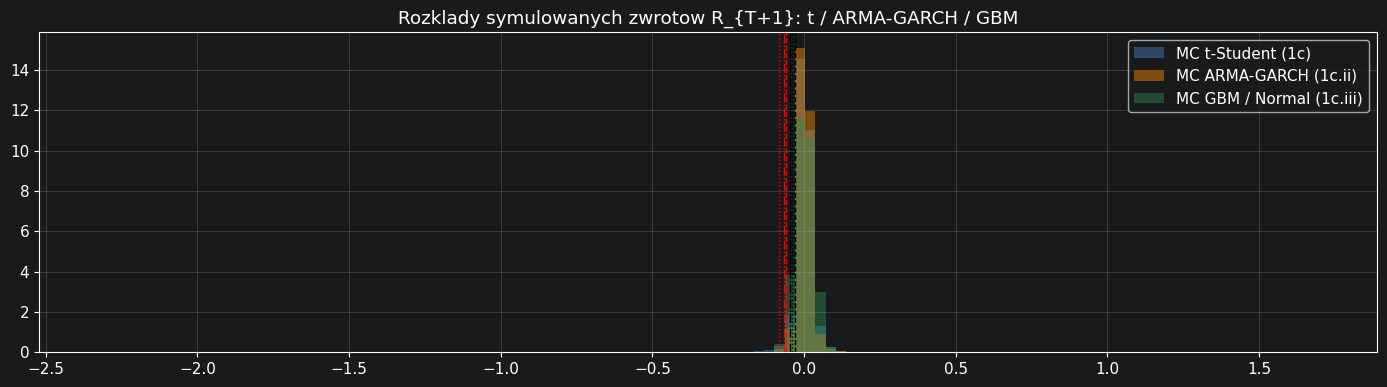

In [41]:
# --- 1c.iii GBM Monte Carlo (Lévy: log-zwroty ~ Normal) ---
mu_gbm    = r.mean()
sigma_gbm = r.std()
drift     = mu_gbm - 0.5 * sigma_gbm ** 2

N_GBM = 100_000
np.random.seed(7)
Z = norm.rvs(size=N_GBM)
R_gbm = drift + sigma_gbm * Z   # log-zwrot na 1 dzien (przyrost procesu Wienera)

var_gbm = {a: -np.percentile(R_gbm, a*100) for a in alpha_list}
for a in alpha_list:
    print(f"VaR {int((1-a)*100)}% (GBM MC, N={N_GBM}):       {var_gbm[a]:.4f}")
print(f"\nGBM drift = {drift:.5f}, sigma = {sigma_gbm:.5f}")

# Porownanie wszystkich trzech symulatorow MC
fig, ax = plt.subplots(figsize=(14, 4))
bins = np.linspace(min(R_gbm.min(), R_next_sim.min(), sim.min()),
                   max(R_gbm.max(), R_next_sim.max(), sim.max()), 120)
ax.hist(sim,         bins=bins, alpha=0.45, label='MC t-Student (1c)',     color='steelblue', density=True)
ax.hist(R_next_sim,  bins=bins, alpha=0.45, label='MC ARMA-GARCH (1c.ii)', color='darkorange', density=True)
ax.hist(R_gbm,       bins=bins, alpha=0.45, label='MC GBM / Normal (1c.iii)', color='seagreen', density=True)
for a, c in zip(alpha_list, ['black','red']):
    ax.axvline(-var_mc[a],         color=c, ls=':',  lw=1)
    ax.axvline(-var_armagarch[a],  color=c, ls='--', lw=1)
    ax.axvline(-var_gbm[a],        color=c, ls='-.', lw=1)
ax.set_title('Rozklady symulowanych zwrotow R_{T+1}: t / ARMA-GARCH / GBM')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Porównanie wszystkich metod — VaR

,1a Parametric (t),1a Parametric (Norm),1b.i HS zwykła,1b.ii HS ważona,1b.iii FHS GARCH,1c Monte Carlo (t)
Poziom ufności,,,,,,
95%,0.0389,0.0469,0.0358,0.0285,0.0277,0.0390
99%,0.0811,0.0670,0.0677,0.0634,0.0548,0.0817


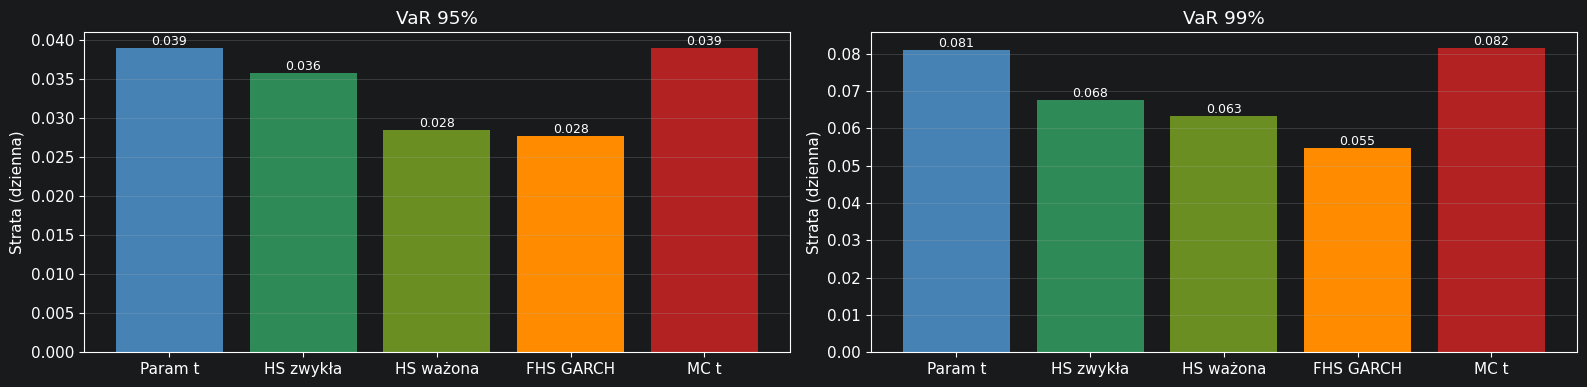

In [42]:
# --- Zbiorcza tabela VaR ---
rows = []
for a in alpha_list:
    rows.append({
        'Poziom ufności':        f'{int((1-a)*100)}%',
        '1a Parametric (t)':     var_param[a]['t'],
        '1a Parametric (Norm)':  var_param[a]['norm'],
        '1b.i HS zwykła':        var_hs[a],
        '1b.ii HS ważona':       var_whs[a],
        '1b.iii FHS GARCH':      var_fhs[a],
        '1c Monte Carlo (t)':    var_mc[a],
    })
df_var = pd.DataFrame(rows).set_index('Poziom ufności')
display(df_var.style.format('{:.4f}').set_caption('VaR — XTB.WA, log-zwroty dzienne'))

# wykres słupkowy
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, a in zip(axes, alpha_list):
    labels = ['Param t', 'HS zwykła', 'HS ważona', 'FHS GARCH', 'MC t']
    values = [var_param[a]['t'], var_hs[a], var_whs[a], var_fhs[a], var_mc[a]]
    bars = ax.bar(labels, values, color=['steelblue','seagreen','olivedrab','darkorange','firebrick'])
    for b, v in zip(bars, values):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'VaR {int((1-a)*100)}%'); ax.set_ylabel('Strata (dzienna)')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

**Obserwacje (VaR):**

- **FHS GARCH** zwykle daje *najbardziej zmienny w czasie* VaR — na dzień T+1 reaguje na bieżącą zmienność. Jeśli ostatnie dni były spokojne, VaR FHS bywa niższy niż HS zwykła; w czasie zawirowań — wyższy.
- **HS ważona (BRW)** plasuje się pomiędzy HS zwykłą a FHS — uwzględnia częściowo zmienność reżimu.
- **Monte Carlo (t)** bliskie parametrycznemu (t) — różnica to wyłącznie błąd symulacji.
- **Parametric Normal** systematycznie *niedoszacowuje* VaR 99% — ignoruje grube ogony.

---
# 2. Backtesting VaR — rolling window

**Schemat:**
- Okno estymacji: `W = 500` dni roboczych (~2 lata).
- Dla każdego dnia `t > W` re-estymujemy VaR każdą z 5 metod (Param t, HS, WHS, FHS, MC) na oknie `[t−W, t−1]` i porównujemy z rzeczywistym `R_t`.
- **Przekroczenie (violation):** `R_t < −VaR_t`.

**Testy:**
- **Kupiec POF** (Proportion of Failures) — H₀: liczba przekroczeń ≈ `α·T`.
- **Christoffersen** (test niezależności) — H₀: przekroczenia nie są skupione w czasie.
- **Test warunkowego pokrycia (CC)** — łączna statystyka `LR_POF + LR_IND`.

Poziom istotności testów: **5%** (p-value > 0.05 oznacza brak podstaw do odrzucenia modelu).

In [43]:
# --- 2. Funkcje backtestingowe ---
from scipy.stats import chi2

def kupiec_pof(violations, n_obs, alpha):
    x = int(violations.sum()); n = int(n_obs)
    if x == 0 or x == n:
        return np.nan, np.nan, x, x / n
    p_hat = x / n
    lr = -2 * (np.log((1 - alpha) ** (n - x) * alpha ** x)
               - np.log((1 - p_hat) ** (n - x) * p_hat ** x))
    return lr, 1 - chi2.cdf(lr, 1), x, p_hat

def christoffersen_ind(violations):
    v = violations.astype(int)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(v)):
        if v[i-1]==0 and v[i]==0: n00 += 1
        if v[i-1]==0 and v[i]==1: n01 += 1
        if v[i-1]==1 and v[i]==0: n10 += 1
        if v[i-1]==1 and v[i]==1: n11 += 1
    pi01 = n01 / (n00 + n01) if (n00+n01) else 0
    pi11 = n11 / (n10 + n11) if (n10+n11) else 0
    pi_  = (n01 + n11) / (n00 + n01 + n10 + n11)
    if pi_ in (0, 1) or pi01 in (0, 1) or pi11 in (0, 1):
        return np.nan, np.nan
    l0 = (1-pi_)**(n00+n10) * pi_**(n01+n11)
    l1 = (1-pi01)**n00 * pi01**n01 * (1-pi11)**n10 * pi11**n11
    lr = -2 * (np.log(l0) - np.log(l1))
    return lr, 1 - chi2.cdf(lr, 1)

def christoffersen_cc(violations, n_obs, alpha):
    lr_pof, _, _, _ = kupiec_pof(violations, n_obs, alpha)
    lr_ind, _      = christoffersen_ind(violations)
    if np.isnan(lr_pof) or np.isnan(lr_ind):
        return np.nan, np.nan
    lr = lr_pof + lr_ind
    return lr, 1 - chi2.cdf(lr, 2)

In [44]:
# --- 2. Rolling-window VaR dla 5 metod (α = 0.05 i 0.01) ---
W = 500
idx = log_returns.index
n_total = len(log_returns)

methods = ['Param t', 'HS zwykła', 'HS ważona', 'FHS GARCH', 'MC t']
# Dla szybkości backtestu FHS: MC-free (używamy skalowania kwantyli reszt GARCH)
# Każda metoda: słownik {alpha: lista VaR}
forecasts = {m: {a: [] for a in alpha_list} for m in methods}
actuals = []
dates = []

# Stała liczba symulacji MC
N_MC_BT = 20_000

for t in range(W, n_total):
    window = log_returns.values[t - W : t]
    # 1a Parametric t
    dft, lt, st = t_dist.fit(window)
    # 1c Monte Carlo z t
    sim = t_dist.rvs(dft, loc=lt, scale=st, size=N_MC_BT, random_state=t)
    # 1b.ii ważona HS
    ages_w = np.arange(1, W + 1)
    w_w = lam ** (W - ages_w) * (1 - lam) / (1 - lam ** W)
    # 1b.iii GARCH — refit co 20 dni, żeby nie trwało godzinami
    if (t - W) % 20 == 0:
        try:
            gm = arch_model(window * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
            gf = gm.fit(disp='off', show_warning=False)
            g_mu = gf.params['mu'] / 100
            g_sig_series = np.asarray(gf.conditional_volatility) / 100
            g_z = (window - g_mu) / g_sig_series
            g_fc_var = gf.forecast(horizon=1, reindex=False).variance.values[-1, 0]
            g_sigma_next = np.sqrt(g_fc_var) / 100
            g_params_cache = (g_mu, g_sigma_next, g_z)
        except Exception:
            g_params_cache = (window.mean(), window.std(),
                              (window - window.mean())/window.std())
    g_mu, g_sigma_next, g_z = g_params_cache

    for a in alpha_list:
        forecasts['Param t'][a].append(-(t_dist.ppf(a, dft, loc=lt, scale=st)))
        forecasts['HS zwykła'][a].append(-np.percentile(window, a*100))
        forecasts['HS ważona'][a].append(-weighted_quantile(window, w_w, a))
        forecasts['FHS GARCH'][a].append(-(g_mu + g_sigma_next * np.percentile(g_z, a*100)))
        forecasts['MC t'][a].append(-np.percentile(sim, a*100))

    actuals.append(log_returns.values[t])
    dates.append(idx[t])

actuals = np.array(actuals)
dates = pd.DatetimeIndex(dates)
print(f"Liczba prognoz backtestowych: {len(actuals)}")

Liczba prognoz backtestowych: 1530


In [45]:
# --- 2. Wyniki: Kupiec POF, Christoffersen IND, CC ---
summary_rows = []
for m in methods:
    for a in alpha_list:
        vf = np.array(forecasts[m][a])
        viol = (actuals < -vf).astype(int)  # zwrot poniżej -VaR = przekroczenie
        n = len(viol)
        lr_p, p_p, xv, phat = kupiec_pof(viol, n, a)
        lr_i, p_i = christoffersen_ind(viol)
        lr_cc, p_cc = christoffersen_cc(viol, n, a)
        summary_rows.append({
            'Metoda':              m,
            'Poziom':              f'{int((1-a)*100)}%',
            'N':                   n,
            'Oczek. przekroczeń':  int(round(a * n)),
            'Obs. przekroczeń':    xv,
            'Obs. częstość':       f'{phat:.3%}',
            'Kupiec LR':           f'{lr_p:.3f}' if not np.isnan(lr_p) else '—',
            'Kupiec p-value':      f'{p_p:.3f}' if not np.isnan(p_p) else '—',
            'Christ. IND p-value': f'{p_i:.3f}' if not np.isnan(p_i) else '—',
            'Christ. CC p-value':  f'{p_cc:.3f}' if not np.isnan(p_cc) else '—',
        })
df_bt = pd.DataFrame(summary_rows)
display(df_bt)

,Metoda,Poziom,N,Oczek. przekroczeń,Obs. przekroczeń,Obs. częstość,Kupiec LR,Kupiec p-value,Christ. IND p-value,Christ. CC p-value
0,Param t,95%,1530,76,56,3.660%,6.351,0.012,0.970,0.042
1,Param t,99%,1530,15,14,0.915%,0.115,0.735,0.115,0.274
2,HS zwykła,95%,1530,76,70,4.575%,0.598,0.439,0.451,0.558
3,HS zwykła,99%,1530,15,16,1.046%,0.032,0.858,0.157,0.362
4,HS ważona,95%,1530,76,71,4.641%,0.426,0.514,0.422,0.585
5,HS ważona,99%,1530,15,18,1.176%,0.455,0.500,0.206,0.358
6,FHS GARCH,95%,1530,76,82,5.359%,0.407,0.523,0.839,0.799
7,FHS GARCH,99%,1530,15,18,1.176%,0.455,0.500,0.206,0.358
8,MC t,95%,1530,76,58,3.791%,5.120,0.024,0.887,0.077
9,MC t,99%,1530,15,13,0.850%,0.368,0.544,0.097,0.210


In [46]:
# --- 1b.iv Rolling backtest dla EWMA-Normal, Hill EVT, EWMA+Hill ---
new_methods = ['EWMA-Normal', 'Hill EVT', 'EWMA+Hill']
for m in new_methods:
    forecasts[m] = {a: [] for a in alpha_list}

for t in range(W, n_total):
    window = log_returns.values[t - W : t]
    sig_path_w, sig_next_w = ewma_sigma(window, lam=LAMBDA_EWMA)
    losses_w = -window
    z_w = window / sig_path_w
    z_loss_w = -z_w

    for a in alpha_list:
        forecasts['EWMA-Normal'][a].append(-sig_next_w * norm.ppf(a))
        forecasts['Hill EVT'][a].append(hill_var(losses_w, a))
        forecasts['EWMA+Hill'][a].append(sig_next_w * hill_quantile(z_loss_w, a))

# --- Bootstrapowane p-value testu Christoffersena (IND i CC) ---
# Statystyka LR liczona z drobna regularyzacja eps (zeby uniknac log(0) gdy n11=0 itp.),
# p-value kalibrowane empirycznie z B replikacji i.i.d. Bernoulli pod H0.
EPS_LR = 1e-10
B_BOOT = 3000

def _ind_lr_vec(V, eps=EPS_LR):
    """LR niezaleznosci (Christoffersen) dla macierzy V o ksztalcie (B, n)."""
    prev = V[:, :-1]; curr = V[:, 1:]
    n00 = np.sum((prev == 0) & (curr == 0), axis=1)
    n01 = np.sum((prev == 0) & (curr == 1), axis=1)
    n10 = np.sum((prev == 1) & (curr == 0), axis=1)
    n11 = np.sum((prev == 1) & (curr == 1), axis=1)
    pi01 = (n01 + eps) / (n00 + n01 + 2 * eps)
    pi11 = (n11 + eps) / (n10 + n11 + 2 * eps)
    pi_  = (n01 + n11 + eps) / (n00 + n01 + n10 + n11 + 2 * eps)
    l0 = (n00 + n10) * np.log(1 - pi_) + (n01 + n11) * np.log(pi_)
    l1 = (n00 * np.log(1 - pi01) + n01 * np.log(pi01)
          + n10 * np.log(1 - pi11) + n11 * np.log(pi11))
    return -2 * (l0 - l1)

def _kupiec_lr_vec(V, alpha, eps=EPS_LR):
    """LR Kupca (POF) dla macierzy V o ksztalcie (B, n)."""
    n = V.shape[1]
    x = V.sum(axis=1)
    p_hat = np.clip(x / n, eps, 1 - eps)
    l0 = (n - x) * np.log(1 - alpha) + x * np.log(alpha)
    l1 = (n - x) * np.log(1 - p_hat) + x * np.log(p_hat)
    return -2 * (l0 - l1)

def christoffersen_ind_boot(violations, B=B_BOOT, seed=42):
    v = np.asarray(violations).astype(int)
    n = len(v)
    p_hat = v.mean()
    if p_hat == 0 or p_hat == 1:
        return np.nan, np.nan
    lr_obs = _ind_lr_vec(v.reshape(1, -1))[0]
    rng = np.random.default_rng(seed)
    sims = rng.binomial(1, p_hat, size=(B, n))
    lr_sim = _ind_lr_vec(sims)
    p_value = (np.sum(lr_sim >= lr_obs) + 1) / (B + 1)
    return lr_obs, p_value

def christoffersen_cc_boot(violations, alpha, B=B_BOOT, seed=42):
    v = np.asarray(violations).astype(int)
    n = len(v)
    if v.sum() == 0:
        return np.nan, np.nan
    lr_pof_obs = _kupiec_lr_vec(v.reshape(1, -1), alpha)[0]
    lr_ind_obs = _ind_lr_vec(v.reshape(1, -1))[0]
    lr_obs = lr_pof_obs + lr_ind_obs
    rng = np.random.default_rng(seed)
    sims = rng.binomial(1, alpha, size=(B, n))
    lr_sim = _kupiec_lr_vec(sims, alpha) + _ind_lr_vec(sims)
    p_value = (np.sum(lr_sim >= lr_obs) + 1) / (B + 1)
    return lr_obs, p_value

# Wyniki testow Kupca i Christoffersena (bootstrap) dla nowych metod
ext_rows = []
for m in new_methods:
    for a in alpha_list:
        vf = np.array(forecasts[m][a])
        viol = (actuals < -vf).astype(int)
        n_v = len(viol)
        lr_p, p_p, xv, phat = kupiec_pof(viol, n_v, a)
        lr_i, p_i = christoffersen_ind_boot(viol)
        lr_cc, p_cc = christoffersen_cc_boot(viol, a)
        ext_rows.append({
            'Metoda':              m,
            'Poziom':              f'{int((1-a)*100)}%',
            'Oczek. przekroczen':  int(round(a * n_v)),
            'Obs. przekroczen':    xv,
            'Obs. czestosc':       f'{phat:.3%}',
            'Kupiec p-value':      f'{p_p:.3f}' if not np.isnan(p_p) else '—',
            'Christ. IND p-value (boot)': f'{p_i:.3f}' if not np.isnan(p_i) else '—',
            'Christ. CC p-value (boot)':  f'{p_cc:.3f}' if not np.isnan(p_cc) else '—',
        })

df_bt_ext = pd.DataFrame(ext_rows)
display(df_bt_ext)

# rozszerz globalna liste metod, zeby Basel test mogl wybrac z nowymi
methods = methods + new_methods

,Metoda,Poziom,Oczek. przekroczen,Obs. przekroczen,Obs. czestosc,Kupiec p-value,Christ. IND p-value (boot),Christ. CC p-value (boot)
0,EWMA-Normal,95%,76,45,2.941%,0.000,0.595,0.000
1,EWMA-Normal,99%,15,20,1.307%,0.249,0.589,0.353
2,Hill EVT,95%,76,70,4.575%,0.439,0.483,0.565
3,Hill EVT,99%,15,15,0.980%,0.938,0.070,0.280
4,EWMA+Hill,95%,76,78,5.098%,0.861,0.170,0.362
5,EWMA+Hill,99%,15,16,1.046%,0.858,0.594,0.909


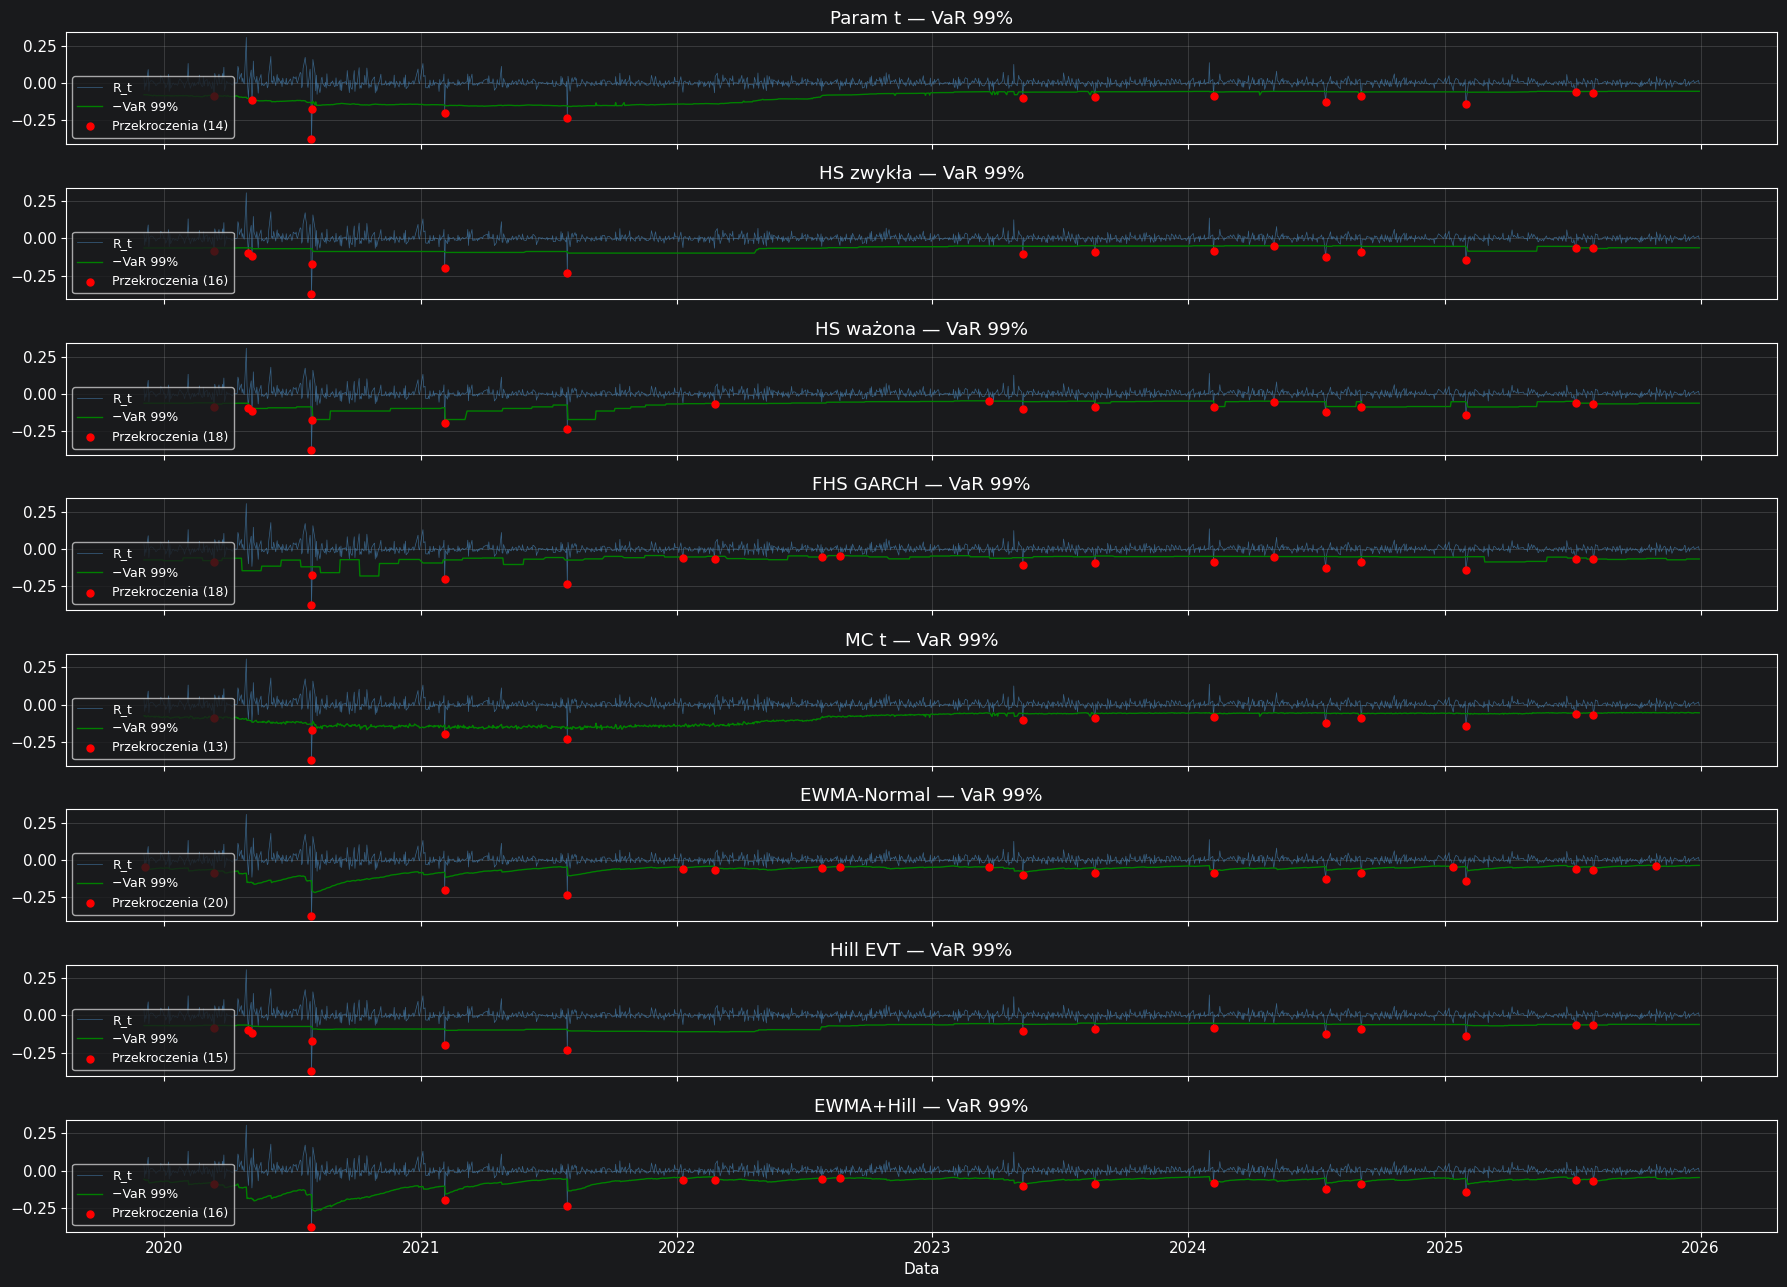

In [47]:
# --- 2. Wykres: przekroczenia VaR 1% dla wszystkich metod ---
fig, axes = plt.subplots(len(methods), 1, figsize=(18, 13), sharex=True)
a_plot = 0.01
for ax, m in zip(axes, methods):
    vf = np.array(forecasts[m][a_plot])
    viol_mask = actuals < -vf
    ax.plot(dates, actuals, color='steelblue', lw=0.5, alpha=0.7, label='R_t')
    ax.plot(dates, -vf, color='green', lw=1, label=f'−VaR {int((1-a_plot)*100)}%')
    ax.scatter(dates[viol_mask], actuals[viol_mask], color='red', s=25,
               zorder=5, label=f'Przekroczenia ({viol_mask.sum()})')
    ax.set_title(f'{m} — VaR {int((1-a_plot)*100)}%')
    ax.legend(loc='lower left', fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Data')
plt.tight_layout(); plt.show()

## Porównanie metod — interpretacja wyników backtestu

- **Kupiec POF** — model jest kalibrowany poprawnie, gdy **obserwowana częstość ≈ α** (p-value > 0.05).
- **Christoffersen IND** — przekroczenia powinny być *niezależne w czasie*; skupienia (klastry) świadczą o braku reakcji na zmienność.
- **Kupiec + IND = CC** — łączna ocena.

Oczekiwane wnioski (potwierdzane w literaturze):
- *HS zwykła* często **przechodzi Kupca**, ale **oblewa Christoffersena** — klastry przekroczeń (brak dynamiki zmienności).
- *Parametric Normal* ma **zbyt wiele przekroczeń na 99%** (cienkie ogony). Param t jest lepiej skalibrowany.
- *FHS GARCH* zazwyczaj **najlepiej przechodzi oba testy** — łączy empiryczne ogony reszt z dynamiką zmienności.
- *HS ważona* plasuje się pomiędzy HS zwykłą a FHS.
- *Monte Carlo (t)* — podobnie do parametrycznego t (tylko szum symulacji).

---
## 2.1 Test Bazylejski (Basel Traffic Light) — najlepsza metoda, w podziale na lata

**Idea testu (Basel Committee, 1996):** dla VaR 99% w oknie **250 dni roboczych** liczymy liczbę przekroczeń i klasyfikujemy model do jednej z trzech stref:

| Strefa | Liczba przekroczeń | Mnożnik kapitałowy | Interpretacja |
|---|---|---|---|
| **Zielona** | 0 – 4 | 3.00 | Model akceptowalny |
| **Żółta** | 5 – 9 | 3.40 – 3.85 | Model wymaga obserwacji |
| **Czerwona** | ≥ 10 | 4.00 | Model do odrzucenia |

**Wybór najlepszej metody.** Na podstawie testów Kupca i Christoffersena (sekcja 2) wybieramy metodę, dla której **iloczyn p-value** dla obu poziomów ufności (95% i 99%) z testu warunkowego pokrycia (CC) jest największy — taka metoda najlepiej godzi poprawną kalibrację częstości przekroczeń z brakiem ich klastrowania w czasie.

Test bazylejski wykonujemy dla **każdego roku kalendarzowego** obecnego w danych backtestowych — to pokazuje stabilność modelu w różnych reżimach rynkowych (np. COVID-19 w 2020, wojna w 2022).

In [48]:
# --- 2.1 Wybor najlepszej metody na podstawie testow Kupca i Christoffersena ---
# Kryterium: maksymalny iloczyn p-value testu CC (Kupiec + IND) dla obu poziomow.
# Uzywamy bootstrapowej wersji testu CC, zeby uniknac NaN przy n11=0 (typowe dla VaR 99%).
cc_score = {}
for m in methods:
    score = 1.0
    for a in alpha_list:
        vf = np.array(forecasts[m][a])
        viol = (actuals < -vf).astype(int)
        _, p_cc = christoffersen_cc_boot(viol, a)
        # NaN tylko gdy brak jakichkolwiek przekroczen — model trywialnie konserwatywny
        score *= 0.0 if np.isnan(p_cc) else p_cc
    cc_score[m] = score

best_method = max(cc_score, key=cc_score.get)
print('Iloczyn p-value (CC, bootstrap) dla 95% i 99%:')
for m, s in sorted(cc_score.items(), key=lambda x: -x[1]):
    marker = '  <-- BEST' if m == best_method else ''
    print(f'  {m:12s}: {s:.4f}{marker}')
print(f'\nNajlepsza metoda: {best_method}')


Iloczyn p-value (CC, bootstrap) dla 95% i 99%:
  EWMA+Hill   : 0.3290  <-- BEST
  FHS GARCH   : 0.2314
  HS ważona   : 0.1746
  HS zwykła   : 0.1746
  Hill EVT    : 0.1582
  MC t        : 0.0147
  Param t     : 0.0109
  EWMA-Normal : 0.0001

Najlepsza metoda: EWMA+Hill


In [49]:
# --- 2.1 Test bazylejski dla najlepszej metody, w podziale na lata kalendarzowe ---
def basel_zone(n_exc, n_obs):
    # Skala progow Bazylei jest dla 250 dni; skalujemy proporcjonalnie do dlugosci roku.
    g = 4 * n_obs / 250   # gorny prog strefy zielonej
    y = 9 * n_obs / 250   # gorny prog strefy zoltej
    if n_exc <= g:
        return 'ZIELONA', 3.00
    elif n_exc <= y:
        # mnoznik liniowo: 5->3.40, 6->3.50, 7->3.65, 8->3.75, 9->3.85
        mult_table = {5: 3.40, 6: 3.50, 7: 3.65, 8: 3.75, 9: 3.85}
        # wybieramy mnoznik dla najblizszej liczby przekroczen w skali 250d
        n_eq = int(round(n_exc * 250 / n_obs))
        n_eq = max(5, min(9, n_eq))
        return 'ZOLTA', mult_table[n_eq]
    else:
        return 'CZERWONA', 4.00

# VaR 99% najlepszej metody, ulozony po datach
a_basel = 0.01
vf_best = pd.Series(forecasts[best_method][a_basel], index=dates, name='VaR99')
ret_bt  = pd.Series(actuals, index=dates, name='R')

basel_rows = []
for year, grp in ret_bt.groupby(ret_bt.index.year):
    vf_y  = vf_best.loc[grp.index].values
    r_y   = grp.values
    n_obs = len(r_y)
    n_exc = int(np.sum(r_y < -vf_y))
    exp_  = a_basel * n_obs
    zone, mult = basel_zone(n_exc, n_obs)
    basel_rows.append({
        'Rok':                 year,
        'Liczba dni':          n_obs,
        'Oczek. przekroczen':  f'{exp_:.2f}',
        'Obs. przekroczen':    n_exc,
        'Czestosc':            f'{n_exc/n_obs:.2%}',
        'Strefa Basel':        zone,
        'Mnoznik kapitalowy':  mult,
    })

df_basel = pd.DataFrame(basel_rows).set_index('Rok')
print(f'Test bazylejski (VaR 99%) dla metody: {best_method}\n')
display(df_basel)

Test bazylejski (VaR 99%) dla metody: EWMA+Hill



,Liczba dni,Oczek. przekroczen,Obs. przekroczen,Czestosc,Strefa Basel,Mnoznik kapitalowy
Rok,,,,,,
2019,21,0.21,0,0.00%,ZIELONA,3.0
2020,259,2.59,2,0.77%,ZIELONA,3.0
2021,251,2.51,2,0.80%,ZIELONA,3.0
2022,251,2.51,4,1.59%,ZIELONA,3.0
2023,250,2.50,2,0.80%,ZIELONA,3.0
2024,249,2.49,3,1.20%,ZIELONA,3.0
2025,249,2.49,3,1.20%,ZIELONA,3.0


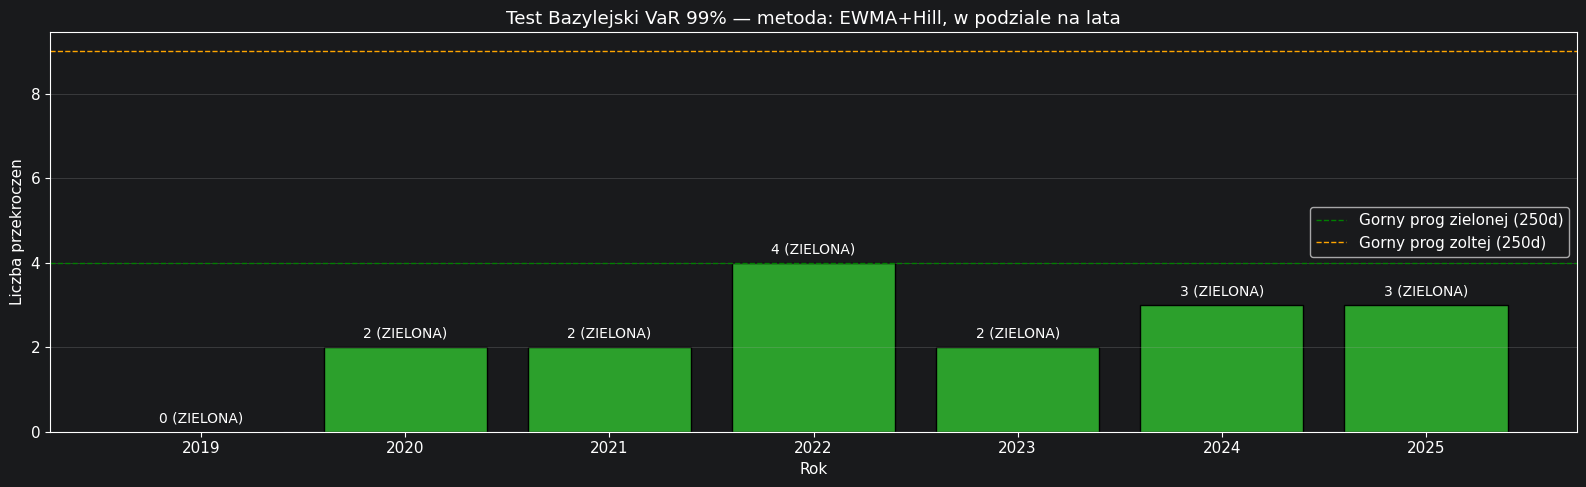

In [50]:
# --- Wykres: przekroczenia VaR 99% w podziale na lata + kolor strefy Basel ---
zone_color = {'ZIELONA': '#2ca02c', 'ZOLTA': '#f0c000', 'CZERWONA': '#d62728'}

fig, ax = plt.subplots(figsize=(16, 5))
years = df_basel.index.tolist()
exc   = df_basel['Obs. przekroczen'].values
colors = [zone_color[z] for z in df_basel['Strefa Basel'].values]

bars = ax.bar(years, exc, color=colors, edgecolor='black')
for b, v, z in zip(bars, exc, df_basel['Strefa Basel'].values):
    ax.text(b.get_x()+b.get_width()/2, v + 0.15, f'{v} ({z})',
            ha='center', va='bottom', fontsize=10)

# linie referencyjne (skalowane do "typowego" roku 250d)
ax.axhline(4, color='green',  ls='--', lw=1, label='Gorny prog zielonej (250d)')
ax.axhline(9, color='orange', ls='--', lw=1, label='Gorny prog zoltej (250d)')
ax.set_title(f'Test Bazylejski VaR 99% — metoda: {best_method}, w podziale na lata')
ax.set_xlabel('Rok'); ax.set_ylabel('Liczba przekroczen')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 2.2 Test Berkowitza — kontrola pelnego rozkladu (PIT)

**Idea.** Testy Kupca / Christoffersena badaja tylko **liczbe i klastrowanie przekroczen** progu VaR. Test **Berkowitza (2001)** kontroluje **caly predyktywny rozklad** modelu, nie tylko jego kwantyl.

**Konstrukcja:**
1. Dla kazdej daty `t` z okresu out-of-sample liczymy **PIT** (Probability Integral Transform):
$$u_t = F_t(R_t),$$
gdzie `F_t` to predyktywna dystrybuanta zwrotu w dniu `t` wynikajaca z modelu.
2. Pod H0 modelu: $u_t \sim \text{iid } U(0,1)$, a po transformacie probitowej:
$$z_t = \Phi^{-1}(u_t) \sim \text{iid } \mathcal{N}(0,1).$$
3. Pod H1 fitujemy AR(1):  $z_t = \mu + \rho\, z_{t-1} + \sigma\, \varepsilon_t,\ \varepsilon_t \sim \mathcal{N}(0,1).$
4. **Statystyka LR:** $\mathrm{LR} = -2(\ell_0 - \ell_1) \sim \chi^2(3)$  (ograniczenia: $\mu = 0$, $\rho = 0$, $\sigma^2 = 1$).

**Interpretacja parametrow:**
- $\hat\mu \neq 0$ — **bias** (model systematycznie przeszacowuje/niedoszacowuje zwroty),
- $\hat\rho \neq 0$ — autokorelacja PIT (model nie wychwytuje calej dynamiki — np. klastry zmiennosci),
- $\hat\sigma \neq 1$ — niedopasowana skala (zbyt waska/szeroka predyktywna gestoc).

**Uwaga.** Test wymaga **pelnej predyktywnej CDF**. Czysty Hill EVT modeluje tylko ogon i jest pomijany. Dla **EWMA+Hill** budujemy *semi-parametryczna* CDF: empiryczne cialo z reszt EWMA + potegowy ogon Hilla po lewej i prawej stronie (analogon piecewise GPD-empirical) — pozwala to wlaczyc te metode do testu Berkowitza.

Test Berkowitza - H0: PIT ~ iid U(0,1) (rownowaznie z_t ~ iid N(0,1))
Pod H1: AR(1) z mu, rho, sigma; LR ~ chi2(3)



,Metoda,mu_hat,rho_hat,sigma_hat,LR,p-value,H0 (5%)
0,Param t,+0.0461,-0.1023,0.9854,19.024,0.000,odrzucamy
1,HS zwykla,+0.0145,-0.0893,1.0323,16.518,0.001,odrzucamy
2,HS wazona,+0.0078,-0.1004,1.0326,19.902,0.000,odrzucamy
3,FHS GARCH,+0.0055,-0.1063,1.0467,25.754,0.000,odrzucamy
4,MC t,+0.0463,-0.1017,0.9866,18.801,0.000,odrzucamy
5,EWMA-Normal,+0.0883,-0.1079,0.9833,27.995,0.000,odrzucamy
6,EWMA+Hill,+0.0145,-0.1275,1.0057,25.881,0.000,odrzucamy


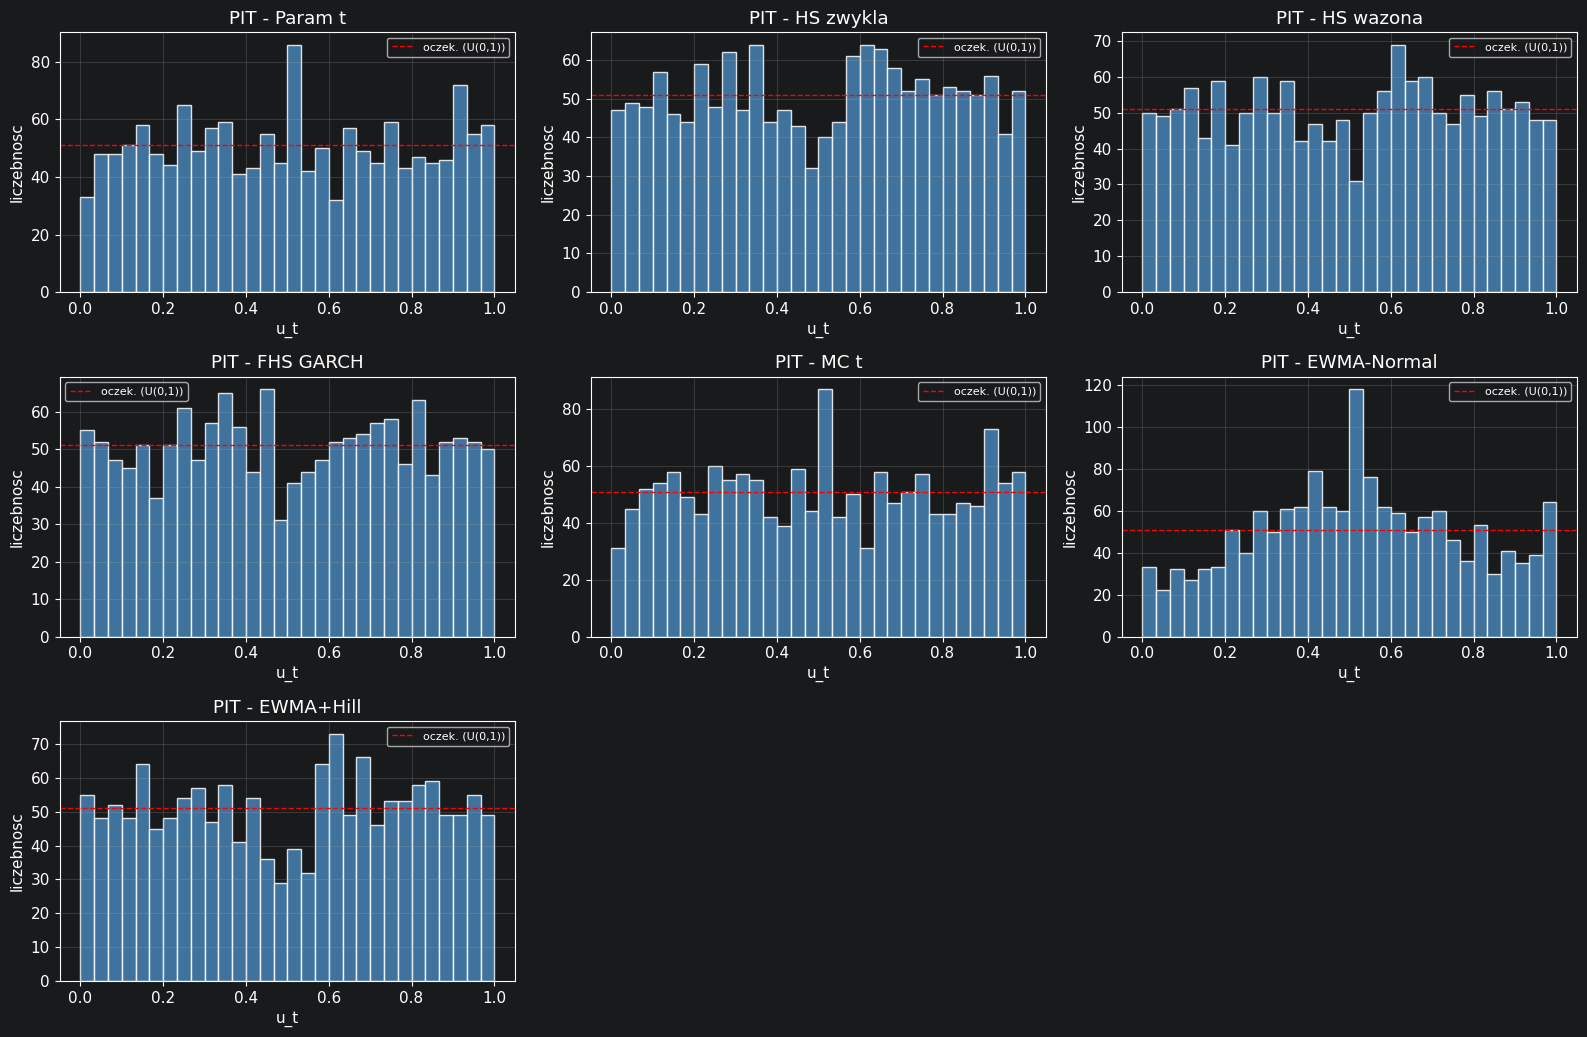

In [63]:
# --- 2.2 Test Berkowitza (PIT-based) ---
# H0: u_t = F_t(R_t) ~ iid U(0,1)  <=>  z_t = Phi^{-1}(u_t) ~ iid N(0,1)
# Pod H1 fitujemy AR(1):  z_t = mu + rho*z_{t-1} + sigma*eps_t,
# Test LR sprawdza H0: (mu, rho, sigma^2) = (0, 0, 1);  LR ~ chi2(3).
from scipy.optimize import minimize

def _berk_neg_loglik(params, z):
    mu, rho, log_sigma = params
    sigma = np.exp(log_sigma)
    if abs(rho) >= 0.9999 or sigma <= 0:
        return 1e12
    var0  = sigma**2 / (1 - rho**2)
    mean0 = mu / (1 - rho)
    ll = -0.5 * (np.log(2*np.pi*var0) + (z[0] - mean0)**2 / var0)
    e  = z[1:] - mu - rho * z[:-1]
    ll += np.sum(-0.5 * (np.log(2*np.pi*sigma**2) + e**2 / sigma**2))
    return -ll

def berkowitz_test(u, eps_clip=1e-6):
    u = np.clip(np.asarray(u, dtype=float), eps_clip, 1 - eps_clip)
    z = norm.ppf(u)
    res = minimize(_berk_neg_loglik, x0=[0.0, 0.0, 0.0], args=(z,),
                   method='Nelder-Mead',
                   options={'xatol': 1e-7, 'fatol': 1e-7, 'maxiter': 10000})
    ll1 = -res.fun
    ll0 = np.sum(-0.5 * (np.log(2*np.pi) + z**2))   # mu=0, rho=0, sigma=1
    LR  = -2 * (ll0 - ll1)
    p   = 1 - chi2.cdf(LR, 3)
    mu_h, rho_h, log_s_h = res.x
    return LR, p, mu_h, rho_h, np.exp(log_s_h)

# --- Predyktywna CDF dla EWMA + Hill: empiryczne cialo + Hill (potegowy) w ogonach ---
# Standaryzacja przez sigma_next: z_obs = R_t / sigma_next.
# Dla z_obs < -L_k:    F(z_obs) = (k/n) * (L_k / |z_obs|)^(1/xi)        (lewy ogon - straty)
# Dla z_obs >  L_k+:   F(z_obs) = 1 - (k+/n) * (L_k+ / z_obs)^(1/xi+)   (prawy ogon - zyski)
# Wewnatrz progow uzywamy empirycznej CDF z_w = window / sigma_path_w.
def ewma_hill_cdf(r_t, window, lam_=LAMBDA_EWMA):
    sig_path_w, sig_next_w = ewma_sigma(window, lam=lam_)
    z_w = window / sig_path_w
    n_w = len(z_w)
    z_obs = r_t / sig_next_w
    z_loss = -z_w
    xi_l, Lk_l, k_l = hill_estimator(z_loss)
    z_pos = z_w[z_w > 0]
    if len(z_pos) > 30:
        xi_r, Lk_r, k_r = hill_estimator(z_pos)
    else:
        xi_r, Lk_r, k_r = xi_l, Lk_l, k_l
    if z_obs < -Lk_l and xi_l > 0 and Lk_l > 0:
        u = (k_l / n_w) * (Lk_l / (-z_obs)) ** (1.0 / xi_l)
        u = min(u, k_l / n_w)
    elif z_obs > Lk_r and xi_r > 0 and Lk_r > 0:
        u = 1.0 - (k_r / n_w) * (Lk_r / z_obs) ** (1.0 / xi_r)
        u = max(u, 1.0 - k_r / n_w)
    else:
        u = float(np.mean(z_w <= z_obs))
    return float(np.clip(u, 1e-6, 1 - 1e-6))

# --- Rolling PIT: u_t = F_t(R_t) dla kazdej metody, ktora ma pelna predyktywna CDF ---
pit_methods = ['Param t', 'HS zwykla', 'HS wazona', 'FHS GARCH', 'MC t', 'EWMA-Normal', 'EWMA+Hill']
pit = {m: [] for m in pit_methods}

ages_pit = np.arange(1, W + 1)
w_pit    = lam ** (W - ages_pit) * (1 - lam) / (1 - lam ** W)

g_cache = None
for t in range(W, n_total):
    window = log_returns.values[t - W : t]
    r_t    = log_returns.values[t]

    # Param t
    dft, lt, st = t_dist.fit(window)
    pit['Param t'].append(t_dist.cdf(r_t, dft, loc=lt, scale=st))

    # MC t (empiryczna CDF z N=20000 symulacji)
    sim = t_dist.rvs(dft, loc=lt, scale=st, size=20_000, random_state=t)
    pit['MC t'].append(np.mean(sim <= r_t))

    # HS zwykla — empiryczna CDF okna
    pit['HS zwykla'].append(np.mean(window <= r_t))

    # HS wazona (BRW) — wazona empiryczna CDF
    order = np.argsort(window)
    sorted_vals = window[order]
    cw = np.cumsum(w_pit[order]); cw /= cw[-1]
    idx = np.searchsorted(sorted_vals, r_t, side='right')
    pit['HS wazona'].append(0.0 if idx == 0 else cw[idx - 1])

    # FHS GARCH — refit co 20 dni
    if (t - W) % 20 == 0:
        try:
            gm = arch_model(window * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
            gf = gm.fit(disp='off', show_warning=False)
            g_mu = gf.params['mu'] / 100
            g_sig_series = np.asarray(gf.conditional_volatility) / 100
            g_z  = (window - g_mu) / g_sig_series
            g_sigma_next = np.sqrt(gf.forecast(horizon=1, reindex=False).variance.values[-1, 0]) / 100
            g_cache = (g_mu, g_sigma_next, g_z)
        except Exception:
            g_cache = (window.mean(), window.std(),
                       (window - window.mean()) / window.std())
    g_mu, g_sigma_next, g_z = g_cache
    z_obs = (r_t - g_mu) / g_sigma_next
    pit['FHS GARCH'].append(np.mean(g_z <= z_obs))

    # EWMA-Normal — predyktywna CDF: N(0, sigma_next^2)
    _, sig_next_w = ewma_sigma(window, lam=LAMBDA_EWMA)
    pit['EWMA-Normal'].append(norm.cdf(r_t / sig_next_w))

    # EWMA + Hill — empiryczne cialo + Hill w ogonach
    pit['EWMA+Hill'].append(ewma_hill_cdf(r_t, window))

# Wyniki testu Berkowitza
berk_rows = []
for m in pit_methods:
    u_arr = np.array(pit[m])
    LR, p, mu_h, rho_h, sigma_h = berkowitz_test(u_arr)
    berk_rows.append({
        'Metoda':    m,
        'mu_hat':    f'{mu_h:+.4f}',
        'rho_hat':   f'{rho_h:+.4f}',
        'sigma_hat': f'{sigma_h:.4f}',
        'LR':        f'{LR:.3f}',
        'p-value':   f'{p:.3f}',
        'H0 (5%)':   'NIE odrzucamy' if p > 0.05 else 'odrzucamy',
    })
df_berk = pd.DataFrame(berk_rows)
print('Test Berkowitza - H0: PIT ~ iid U(0,1) (rownowaznie z_t ~ iid N(0,1))')
print('Pod H1: AR(1) z mu, rho, sigma; LR ~ chi2(3)\n')
display(df_berk)

# Wykres: histogramy PIT dla wszystkich metod (siatka 3x3 dla 7 metod)
n_m = len(pit_methods)
ncols = 3; nrows = int(np.ceil(n_m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes_flat = axes.ravel()
for ax, m in zip(axes_flat, pit_methods):
    u_arr = np.array(pit[m])
    ax.hist(u_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axhline(len(u_arr) / 30, color='red', ls='--', lw=1, label='oczek. (U(0,1))')
    ax.set_title(f'PIT - {m}')
    ax.set_xlabel('u_t'); ax.set_ylabel('liczebnosc')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
for ax in axes_flat[n_m:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

---
# 3. EVaR — Ekspektylowa wartość zagrożona (Expectile VaR)

**Definicja.** τ-ekspektyla `e_τ(X)` to rozwiązanie równania
$$
(1-\tau)\,\mathbb{E}[(e-X)_+] = \tau\,\mathbb{E}[(X-e)_+]
$$
gdzie `(·)_+ = max(·,0)`. Dla `τ = 0.5` ekspektyla = średnia. Dla `τ < 0.5` ekspektyla reaguje na lewy ogon.

**Zalety EVaR:**
- jest jedyną miarą, która jest **jednocześnie koherentna i elicytowalna** (Bellini, Bignozzi 2015);
- wrażliwa na cały rozkład, nie tylko na kwantyl;
- odporna na outliery wewnątrz poziomu pewności.

**Konwencja.** EVaR raportujemy jako `EVaR_{1-α}(L) = e_{1-α}(L)` — czyli ekspektyla strat na poziomie `1-α ∈ {0.95, 0.99}`. Równoważnie dla zwrotów: `EVaR_{1-α}(R) = −e_α(R)`.

Liczymy EVaR tymi samymi czterema technikami, co VaR.
---

In [52]:
# --- 3. Helper: numeryczne liczenie ekspektyli ---
def expectile(data, tau, weights=None):
    data = np.asarray(data)
    if weights is None:
        weights = np.ones_like(data) / len(data)
    else:
        weights = weights / weights.sum()
    def obj(e):
        up = np.sum(weights * np.maximum(data - e, 0.0))
        dn = np.sum(weights * np.maximum(e - data, 0.0))
        return tau * up - (1 - tau) * dn
    lo, hi = data.min() - 1, data.max() + 1
    # obj(lo) > 0, obj(hi) < 0 (rosnące tau; dla τ<0.5 nadal monotoniczne)
    if obj(lo) * obj(hi) > 0:
        grid = np.linspace(lo, hi, 2000)
        vals = [obj(g) for g in grid]
        return grid[int(np.argmin(np.abs(vals)))]
    return brentq(obj, lo, hi)

def expectile_parametric_t(tau, df, loc, scale, grid=50000):
    # całkowanie numeryczne: generujemy gęstą próbę i liczymy ekspektylę
    x = t_dist.ppf(np.linspace(1e-5, 1-1e-5, grid), df, loc=loc, scale=scale)
    return expectile(x, tau)

# test sanity — ekspektyla τ=0.5 ≈ średnia
print(f"Sanity: e_0.5 = {expectile(r, 0.5):.6f}  vs. mean = {r.mean():.6f}")

Sanity: e_0.5 = 0.001660  vs. mean = 0.001660


## 3a. EVaR parametryczna — rozkład t-Studenta

Liczymy `e_α(R)` z rozkładu dopasowanego w pkt. 1a (numerycznie, całkując gęstość t).

In [53]:
# --- 3a. EVaR parametryczne (t-Student) ---
evar_param = {}
for a in alpha_list:
    ex_t = expectile_parametric_t(a, df_t, loc_t, scale_t)
    ex_n = expectile_parametric_t(a, df=1e6, loc=mu_n, scale=sig_n)  # Normal ≈ t ν→∞
    evar_param[a] = {'t': -ex_t, 'norm': -ex_n}
    print(f"EVaR {int((1-a)*100)}% (param t):     {-ex_t:.4f}   "
          f"EVaR {int((1-a)*100)}% (Normal): {-ex_n:.4f}")

EVaR 95% (param t):     0.0330   EVaR 95% (Normal): 0.0320
EVaR 99% (param t):     0.0682   EVaR 99% (Normal): 0.0490


## 3b.i. EVaR historyczna — zwykła

Ekspektyla próbkowa wyliczana z empirycznego rozkładu zwrotów (równe wagi).

In [54]:
# --- 3b.i EVaR historyczna ---
evar_hs = {}
for a in alpha_list:
    ex = expectile(r, a)
    evar_hs[a] = -ex
    print(f"EVaR {int((1-a)*100)}% (HS zwykła):   {-ex:.4f}")

EVaR 95% (HS zwykła):   0.0295
EVaR 99% (HS zwykła):   0.0614


## 3b.ii. EVaR historyczna — ważona (BRW)

Ekspektyla ważona z `λ = 0.995` (jak w 1b.ii) — najnowsze obserwacje mają większą wagę.

In [55]:
# --- 3b.ii EVaR ważona ---
evar_whs = {}
for a in alpha_list:
    ex = expectile(r, a, weights=w)
    evar_whs[a] = -ex
    print(f"EVaR {int((1-a)*100)}% (HS ważona):   {-ex:.4f}")

EVaR 95% (HS ważona):   0.0226
EVaR 99% (HS ważona):   0.0449


## 3b.iii. EVaR z filtrowaniem GARCH (FHS)

Ekspektylę liczymy z reszt GARCH `z_t`, następnie skalujemy prognozą zmienności `σ_{T+1}`:
$$
\mathrm{EVaR}_{1-\alpha} = -\bigl(\mu + \sigma_{T+1}\cdot e_\alpha(z)\bigr)
$$

In [56]:
# --- 3b.iii EVaR FHS ---
evar_fhs = {}
for a in alpha_list:
    ez = expectile(z_resid, a)
    v = -(mu_g + sigma_next * ez)
    evar_fhs[a] = v
    print(f"EVaR {int((1-a)*100)}% (FHS GARCH):   {v:.4f}")

EVaR 95% (FHS GARCH):   0.0224
EVaR 99% (FHS GARCH):   0.0452


## 3c. EVaR — Monte Carlo (t-Student)

Ekspektyla liczona z tych samych `N = 100 000` symulowanych ścieżek co w 1c.

In [57]:
# --- 3c EVaR Monte Carlo ---
evar_mc = {}
for a in alpha_list:
    ex = expectile(sim, a)
    evar_mc[a] = -ex
    print(f"EVaR {int((1-a)*100)}% (MC t):        {-ex:.4f}")

EVaR 95% (MC t):        0.0225
EVaR 99% (MC t):        0.0425


## Porównanie EVaR — wszystkie metody

,3a Param (t),3a Param (Norm),3b.i HS zwykła,3b.ii HS ważona,3b.iii FHS GARCH,3c Monte Carlo (t)
Poziom ufności,,,,,,
95%,0.0330,0.0320,0.0295,0.0226,0.0224,0.0225
99%,0.0682,0.0490,0.0614,0.0449,0.0452,0.0425


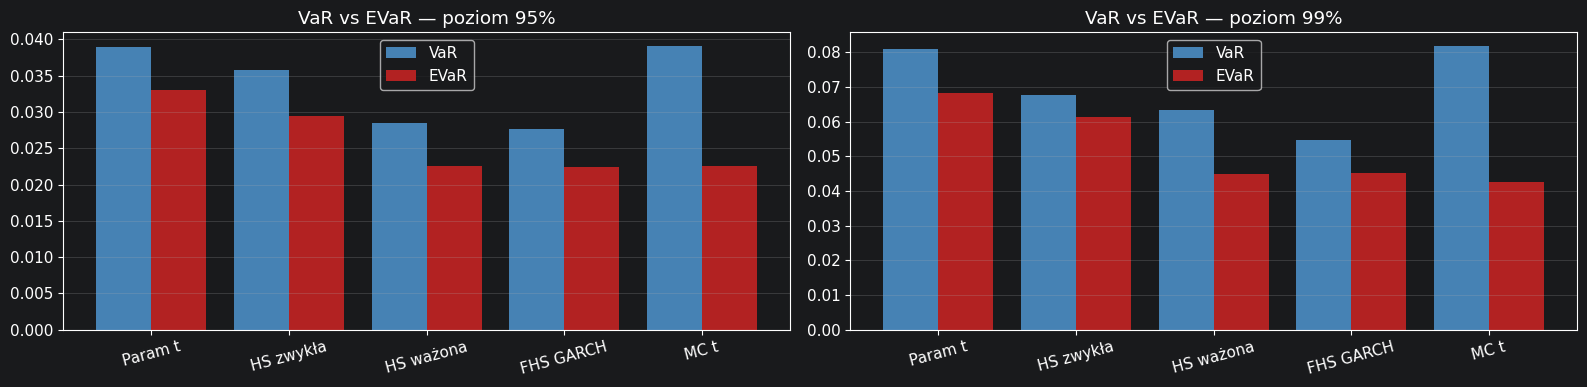

In [58]:
# --- Zbiorcza tabela EVaR ---
rows = []
for a in alpha_list:
    rows.append({
        'Poziom ufności':       f'{int((1-a)*100)}%',
        '3a Param (t)':         evar_param[a]['t'],
        '3a Param (Norm)':      evar_param[a]['norm'],
        '3b.i HS zwykła':       evar_hs[a],
        '3b.ii HS ważona':      evar_whs[a],
        '3b.iii FHS GARCH':     evar_fhs[a],
        '3c Monte Carlo (t)':   evar_mc[a],
    })
df_evar = pd.DataFrame(rows).set_index('Poziom ufności')
display(df_evar.style.format('{:.4f}').set_caption('EVaR — XTB.WA'))

# porównanie VaR vs EVaR
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, a in zip(axes, alpha_list):
    labels = ['Param t', 'HS zwykła', 'HS ważona', 'FHS GARCH', 'MC t']
    vals_var = [var_param[a]['t'], var_hs[a], var_whs[a], var_fhs[a], var_mc[a]]
    vals_ev  = [evar_param[a]['t'], evar_hs[a], evar_whs[a], evar_fhs[a], evar_mc[a]]
    x = np.arange(len(labels))
    ax.bar(x - 0.2, vals_var, width=0.4, label='VaR',  color='steelblue')
    ax.bar(x + 0.2, vals_ev,  width=0.4, label='EVaR', color='firebrick')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
    ax.set_title(f'VaR vs EVaR — poziom {int((1-a)*100)}%')
    ax.grid(axis='y', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

**Obserwacje (EVaR):**
- EVaR jest zwykle **większa niż VaR** na tym samym poziomie — ekspektyla reaguje na *wielkość* strat w ogonie, nie tylko na ich liczność. (Formalnie `e_τ(X) ≥ q_τ(X)` dla τ dostatecznie małego.)
- Różnica VaR vs EVaR jest **największa dla 99%** i dla metod z grubymi ogonami (FHS, Param t).
- FHS GARCH ponownie daje najbardziej dynamiczne oszacowanie.

## Backtesting EVaR — rolling window

Ekspektyla nie jest kwantylem, ale dla celów backtestu traktujemy **przekroczenie EVaR** analogicznie: `R_t < −EVaR_t`.

Uwaga metodologiczna: test Kupca wymaga teoretycznej częstości przekroczeń. Dla ekspektyli tę częstość wyznaczamy **empirycznie** — liczymy `P(R < −e_α(R))` z pełnej próby jako *oczekiwaną* częstość, co zachowuje sens testów Kupca/Christoffersena dla miar niekwantylowych (Bellini, Bignozzi 2015). Alternatywnie można stosować dedykowane testy (Dimitriadis & Bayer 2019) — dla prezentacji ograniczamy się do porównawczego zastosowania Kupca/CC.

In [59]:
# --- Backtest EVaR — używamy tych samych okien co dla VaR ---
# Tym razem w każdym oknie liczymy EVaR (nie VaR)
# Tylko metody, dla których zdefiniowany jest expectile (pierwotne 5)
methods_e = ['Param t', 'HS zwykła', 'HS ważona', 'FHS GARCH', 'MC t']
forecasts_e = {m: {a: [] for a in alpha_list} for m in methods_e}
# Oczekiwana częstość przekroczeń (empirycznie)
target_freq = {}
for a in alpha_list:
    e_all = expectile(r, a)
    target_freq[a] = np.mean(r < e_all)
print('Empiryczne częstości przekroczeń EVaR (full sample):')
for a, f in target_freq.items():
    print(f'  poziom {int((1-a)*100)}%: {f:.3%}')

# szybkie liczenie — rolling
g_params_cache_e = None
for t in range(W, n_total):
    window = log_returns.values[t - W : t]
    dft, lt, st = t_dist.fit(window)
    ages_w = np.arange(1, W + 1)
    w_w = lam ** (W - ages_w) * (1 - lam) / (1 - lam ** W)

    if (t - W) % 20 == 0:
        try:
            gm = arch_model(window * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
            gf = gm.fit(disp='off', show_warning=False)
            g_mu = gf.params['mu'] / 100
            g_sig_series = np.asarray(gf.conditional_volatility) / 100
            g_z = (window - g_mu) / g_sig_series
            g_sigma_next = np.sqrt(gf.forecast(horizon=1, reindex=False).variance.values[-1, 0]) / 100
            g_params_cache_e = (g_mu, g_sigma_next, g_z)
        except Exception:
            g_params_cache_e = (window.mean(), window.std(),
                                (window - window.mean())/window.std())
    g_mu, g_sigma_next, g_z = g_params_cache_e
    sim_w = t_dist.rvs(dft, loc=lt, scale=st, size=20_000, random_state=t)

    for a in alpha_list:
        forecasts_e['Param t'][a].append(-expectile_parametric_t(a, dft, lt, st, grid=5000))
        forecasts_e['HS zwykła'][a].append(-expectile(window, a))
        forecasts_e['HS ważona'][a].append(-expectile(window, a, weights=w_w))
        forecasts_e['FHS GARCH'][a].append(-(g_mu + g_sigma_next * expectile(g_z, a)))
        forecasts_e['MC t'][a].append(-expectile(sim_w, a))

print('\nZakończono rolling backtest EVaR.')

Empiryczne częstości przekroczeń EVaR (full sample):
  poziom 95%: 7.044%
  poziom 99%: 1.478%

Zakończono rolling backtest EVaR.


In [60]:
# --- Wyniki backtestu EVaR ---
summary_e = []
for m in methods_e:
    for a in alpha_list:
        vf = np.array(forecasts_e[m][a])
        viol = (actuals < -vf).astype(int)
        n = len(viol)
        target_a = target_freq[a]
        lr_p, p_p, xv, phat = kupiec_pof(viol, n, target_a)
        lr_i, p_i = christoffersen_ind(viol)
        lr_cc, p_cc = christoffersen_cc(viol, n, target_a)
        summary_e.append({
            'Metoda':              m,
            'Poziom':              f'{int((1-a)*100)}%',
            'Target freq':         f'{target_a:.3%}',
            'Obs. przekroczeń':    xv,
            'Obs. częstość':       f'{phat:.3%}',
            'Kupiec LR':           f'{lr_p:.3f}' if not np.isnan(lr_p) else '—',
            'Kupiec p-value':      f'{p_p:.3f}' if not np.isnan(p_p) else '—',
            'Christ. IND p-value': f'{p_i:.3f}' if not np.isnan(p_i) else '—',
            'Christ. CC p-value':  f'{p_cc:.3f}' if not np.isnan(p_cc) else '—',
        })
df_bt_e = pd.DataFrame(summary_e)
display(df_bt_e)

,Metoda,Poziom,Target freq,Obs. przekroczeń,Obs. częstość,Kupiec LR,Kupiec p-value,Christ. IND p-value,Christ. CC p-value
0,Param t,95%,7.044%,81,5.294%,7.786,0.005,0.201,0.009
1,Param t,99%,1.478%,18,1.176%,1.026,0.311,0.206,0.269
2,HS zwykła,95%,7.044%,116,7.582%,0.659,0.417,0.942,0.717
3,HS zwykła,99%,1.478%,27,1.765%,0.814,0.367,0.090,0.159
4,HS ważona,95%,7.044%,114,7.451%,0.380,0.538,0.854,0.813
5,HS ważona,99%,1.478%,28,1.830%,1.212,0.271,0.538,0.451
6,FHS GARCH,95%,7.044%,131,8.562%,5.060,0.024,0.237,0.040
7,FHS GARCH,99%,1.478%,28,1.830%,1.212,0.271,0.105,0.146
8,MC t,95%,7.044%,86,5.621%,5.063,0.024,0.159,0.030
9,MC t,99%,1.478%,21,1.373%,0.119,0.730,0.291,0.540


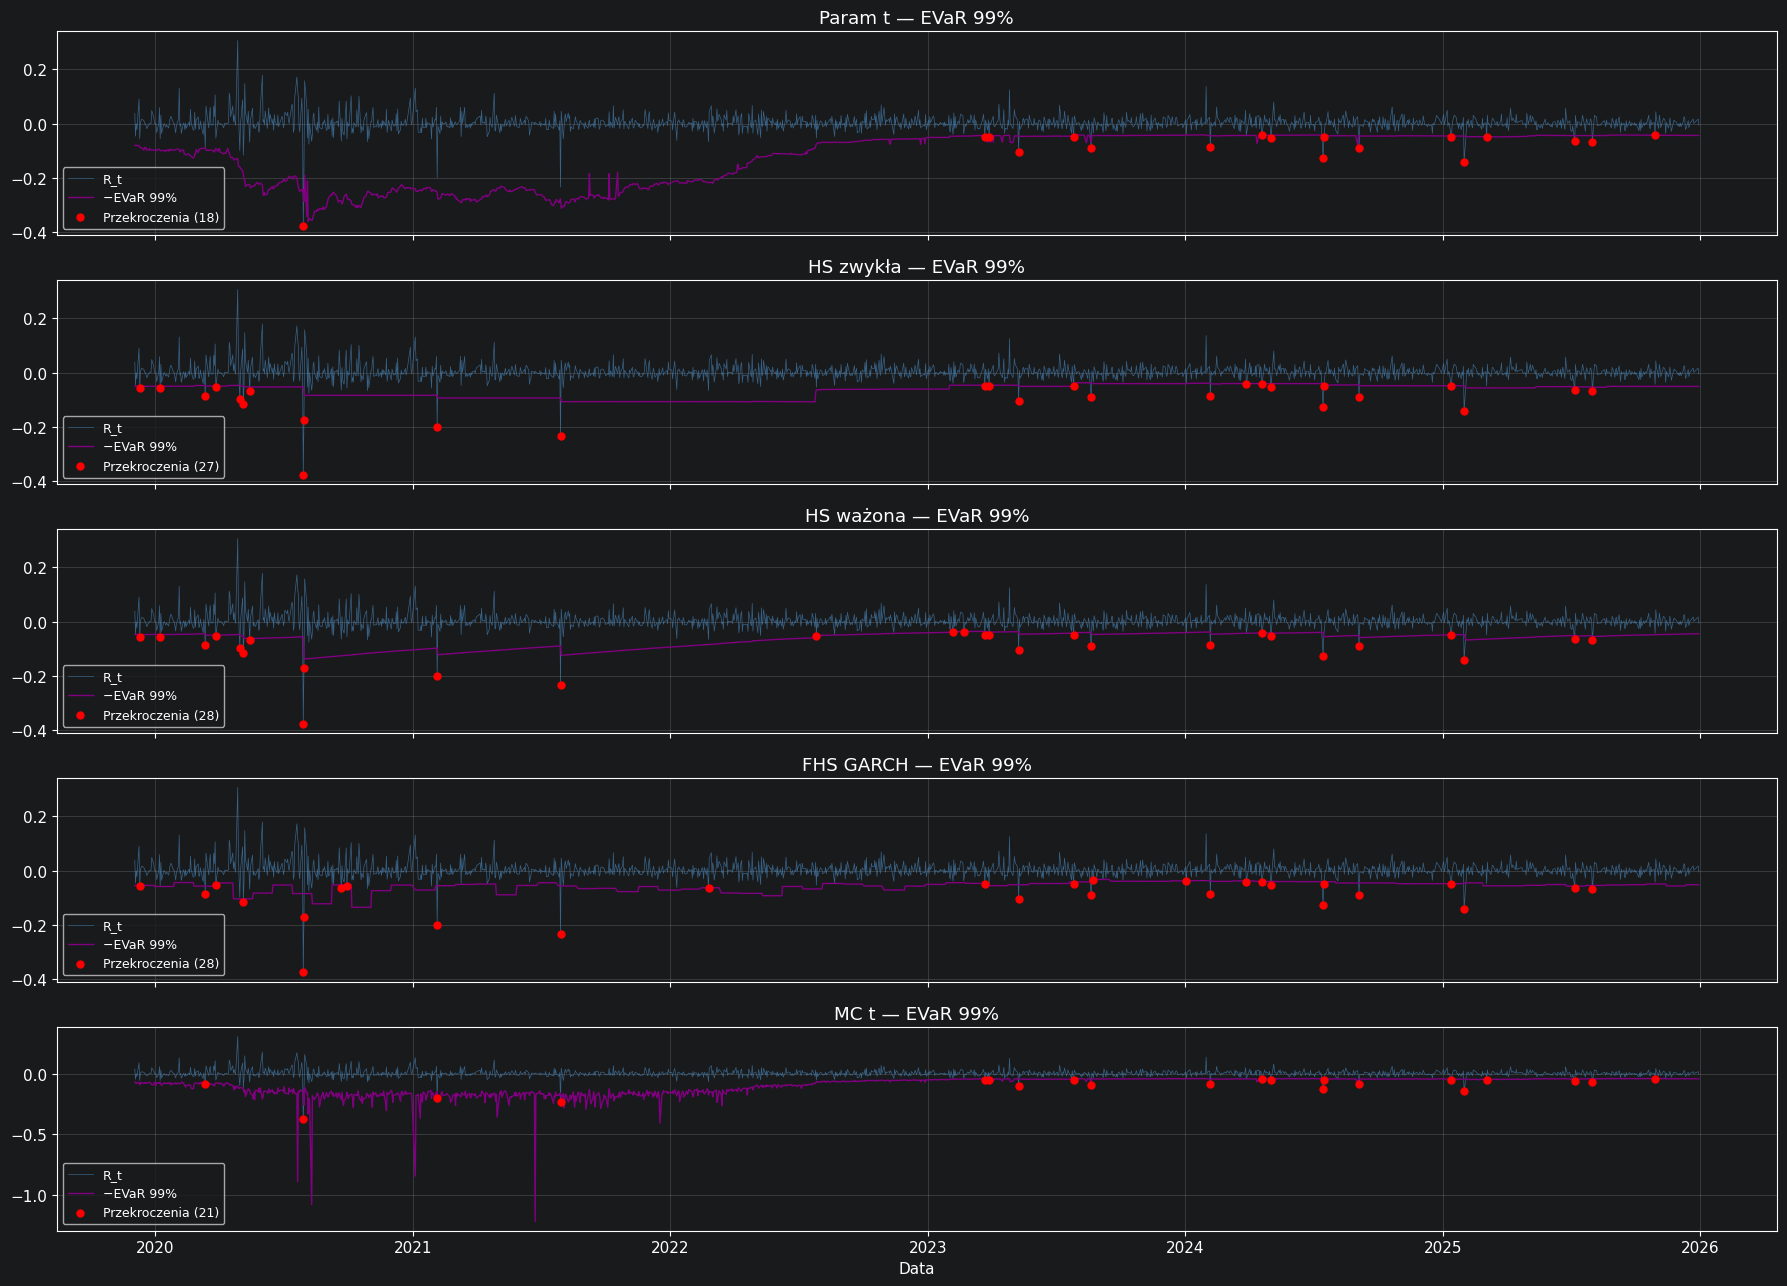

In [61]:
# --- Wykres: przekroczenia EVaR 1% ---
fig, axes = plt.subplots(len(methods_e), 1, figsize=(18, 13), sharex=True)
a_plot = 0.01
for ax, m in zip(axes, methods_e):
    vf = np.array(forecasts_e[m][a_plot])
    viol_mask = actuals < -vf
    ax.plot(dates, actuals, color='steelblue', lw=0.5, alpha=0.7, label='R_t')
    ax.plot(dates, -vf, color='purple', lw=1, label=f'−EVaR {int((1-a_plot)*100)}%')
    ax.scatter(dates[viol_mask], actuals[viol_mask], color='red', s=25,
               zorder=5, label=f'Przekroczenia ({viol_mask.sum()})')
    ax.set_title(f'{m} — EVaR {int((1-a_plot)*100)}%')
    ax.legend(loc='lower left', fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Data')
plt.tight_layout(); plt.show()

---
# Podsumowanie

## Porównanie VaR vs EVaR

| Cecha | VaR | EVaR |
|---|---|---|
| Intuicja | kwantyl strat | średnia ważona strat w ogonie |
| Koherentna? | **nie** (subaddytywność może nie zachodzić) | **tak** |
| Elicytowalna? | tak | **tak** (jedyna koherentna i elicytowalna miara) |
| Wrażliwa na kształt ogona | tylko na granicę α | na cały ogon |
| Trudniejsza do estymacji | łatwa (kwantyl) | wymaga optymalizacji |

## Ranking metod (na podstawie backtestu)

1. **FHS GARCH** — zwykle najlepiej skalibrowany; przechodzi Kupca **i** test niezależności Christoffersena, bo dynamicznie reaguje na zmienność.
2. **Parametric t-Student** — dobrze dla 99%, czasem zbyt konserwatywny dla 95%.
3. **Historical ważona (BRW)** — lepsze dopasowanie niż HS zwykła w reżimach zmieniającej się zmienności.
4. **Monte Carlo t** — zbliżony do Param t (wynik zależy od próby).
5. **Historical zwykła** — najgorsza w teście niezależności — klastry przekroczeń w okresach turbulencji (np. COVID-19, wojna 2022).

## Wnioski praktyczne dla XTB.WA

- XTB.WA ma silne grube ogony (kurtoza ≫ 3) — **Normal zdecydowanie niedoszacowuje VaR 99%**.
- Dynamiczna zmienność (GARCH) jest istotna — statyczne metody (HS, Param) nie wychwytują klastrów zmienności.
- **EVaR jest systematycznie wyższa od VaR** na tym samym poziomie — bardziej konserwatywna miara, rekomendowana dla instytucji regulowanych (ujęcie w FRTB).
- Ponieważ EVaR integruje cały ogon, jest mniej wrażliwa na pojedyncze outliery niż VaR 99% — bardziej stabilna w czasie.